In [1]:
!pip install torchsummary
!pip install torchmetrics
!pip install git+https://github.com/fangwei123456/spikingjelly.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.7 MB/s eta 0:00:00
  Cloning https://github.com/fangwei123456/spikingjelly.git to /tmp/pip-req-build-yis11tb8
  Running command git clone --filter=blob:none --quiet https://github.com/fangwei123456/spikingjelly.git /tmp/pip-req-build-yis11tb8
  Resolved https://github.com/fangwei123456/spikingjelly.git to commit bf0a37a65015d2acf0687ba0e3a91fe2974aea34
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.1 MB/s eta 0:00:00
  Created wheel for spikingjelly: filename=spikingjelly-2.0.0-py3-none-any.whl size=996420 sha256=fba5533796fef1418d3be74c18f97c5482752246c531435499d1bd16fc6b120c
  Stored in directory: /tmp/pip-ephem-wheel-cache-v3uprkyt/wheels/3f/f3/a4/52426a0984dd820987b871e42d7896bfb8ee7558a5f43d4db1
Successfully built spikingjelly


In [2]:
!python --version

Python 3.13.15


In [3]:
%matplotlib inline

# import
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision
import numpy as np
from torchsummary import summary # Libraries for previewing neural network architectures
from spikingjelly.activation_based import neuron, encoding, functional, surrogate
from spikingjelly import visualizing
from matplotlib import pyplot as plt
import time

In [4]:
import inspect

print("=== Encoding ===")
print(dir(encoding))


=== Encoding ===
['F', 'LatencyEncoder', 'PeriodicEncoder', 'PoissonEncoder', 'PopEncoder', 'PopSpikeEncoderDeterministic', 'PopSpikeEncoderRandom', 'StatefulEncoder', 'StatelessEncoder', 'WeightedPhaseEncoder', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_population_activity', '_population_parameters', 'abstractmethod', 'base', 'functional', 'math', 'neuron', 'nn', 'surrogate', 'torch']


In [5]:
# Configure basic information
# Configure the hardware platform
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")
# Specify the dataset directory
dataset_dir = './dataset' # Dataset directory
# Specify the dataset's batch_size
batch_size = 64
# Set the directory for auto-saving models
# Be sure to create this directory beforehand
model_auto_save_dir = './model_save/auto_save/'
# Set the directory for manually saving models
# Make sure the folder has been created
model_history_save_dir = './model_save/history_save/'
# Set the path to the external image
# Make sure the image is present in the corresponding folder; if no external image is available, comment out this line of code
# img_path = “./dataset/images1.jpg”
# Do not print ellipses in Jupyter output; disabling this is recommended when there are too many network parameters
# torch.set_printoptions(threshold=np.inf)

os.makedirs(model_auto_save_dir, exist_ok=True)
os.makedirs(model_history_save_dir, exist_ok=True)

device: cuda:0


In [6]:
# Import the dataset

# Load the training dataset
train_dataset = torchvision.datasets.MNIST(
    root=dataset_dir,
    train=True,
    transform=torchvision.transforms.ToTensor(),
    download=True
)
# Load the test dataset
test_dataset = torchvision.datasets.MNIST(
    root=dataset_dir,
    train=False,
    transform=torchvision.transforms.ToTensor(),
    download=True
)
# Print the size of the training dataset
train_dataset_size = len(train_dataset)
print(f"Training dataset size: {train_dataset_size}")
# Print the size of the test dataset
test_dataset_size = len(test_dataset)
print(f"Test dataset size: {test_dataset_size}")

# Load the training data using DataLoader
train_dataloader = data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    pin_memory=True
)
# Load the test data using DataLoader
test_dataloader = data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 124kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.40MB/s]


Training dataset size: 60000
Test dataset size: 10000


In [7]:
isinstance(train_dataset, torch.utils.data.Dataset)

True

## ANN

In [8]:
from torch.utils.data import random_split

# Load the original test dataset
test_dataset_full = test_dataset

# Split original test set 50/50 into validation and test
val_size = len(test_dataset_full) // 2
test_size = len(test_dataset_full) - val_size

a_val_dataset, a_test_dataset = random_split(
    test_dataset_full,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training:   {len(train_dataset)}")
print(f"Validation: {len(a_val_dataset)}")
print(f"Test:       {len(a_test_dataset)}")

Training:   60000
Validation: 5000
Test:       5000


In [9]:
NUM_CLASSES  = len(train_dataset.classes)
CLASS_NAMES  = train_dataset.classes
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(a_val_dataset)} | Test: {len(a_test_dataset)}")

Classes (10): ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Train: 60000 | Val: 5000 | Test: 5000


In [10]:
# Load the test data using DataLoader
a_test_dataloader = data.DataLoader(
    dataset=a_test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

# Load the test data using DataLoader
a_val_dataloader = data.DataLoader(
    dataset=a_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

In [11]:
import os, re, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch.optim import Optimizer, Adam, AdamW, SGD
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import timm
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import  ImageFolder
from collections import Counter
from torchvision.transforms import ToTensor
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score


In [12]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")

In [13]:
from sklearn.model_selection import train_test_split
from pathlib import Path

from tqdm import tqdm
from typing import Tuple, Union, Callable

CriterionType = Union[
    nn.Module,
    Callable[[torch.Tensor, torch.Tensor], torch.Tensor]
]

In [14]:
class ANN(nn.Module):
  @property
  def has_backbone(): return False

  def __init__(self, num_classes=8):
      super().__init__()
      # convolutions & pooling layers
      self.features = nn.Sequential(
          # Block 1: 1 conv layer
          nn.LazyConv2d(32, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2), # from 224 to 112

          # Block 2: 1 conv layer
          nn.LazyConv2d(64, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2), # from 112 to 56
      )

      # fully-connected layers
      self.classifier = nn.Sequential(
          nn.Flatten(),  # flat tensor to vector
          nn.LazyLinear(512),
          nn.ReLU(),
          nn.Dropout(p=0.4),
          nn.LazyLinear(256),
          nn.ReLU(),
          nn.LazyLinear(num_classes)
      )

  def forward(self, x):
    x = self.features(x)
    output = self.classifier(x)
    return output

In [15]:
class ANNV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1),
            nn.BatchNorm2d(32, eps=1e-3),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(32, 32, 3, 1),
            nn.BatchNorm2d(32, eps=1e-3),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(32, 32, 3, 1),
            nn.BatchNorm2d(32, eps=1e-3),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(32, 10),
            nn.ReLU()
        )

    def forward(self,x):
        x = self.network(x)
        return x

In [16]:
MAX_EPOCH_LIMIT = 30

In [17]:
CHECKPOINT_DIR = Path("./model_save/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

In [18]:
def get_backbone(model: nn.Module):
    """Return the backbone module for freezing (works for all model types)."""
    for attr in ["backbone", "base", "base_model", "features"]:
        if hasattr(model, attr):
            return getattr(model, attr)
    return None

# a function for training one epoch
def train_one_epoch(model: nn.Module, dataloader: DataLoader, optimizer: Optimizer, criterion: CriterionType, epoch: int, max_epoch: int) -> Tuple[float, float]:
  # Prepare for storing loss and accuracy
  losses = MeanMetric().to(DEVICE)
  acc = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(DEVICE)
  model.train() # set model to train mode
  # a loop to iterate input(X)[image] and label(Y) for all mini-batches
  for X, y in tqdm(dataloader, desc=f"Epoch {epoch+1}/{max_epoch} Training Loop", leave=False):
      X, y = X.to(DEVICE), y.to(DEVICE)
      optimizer.zero_grad() # reset optimizer
      preds = model(X) # model forward
      loss = criterion(preds, y) # calculate loss
      loss.backward() # compute gradients via backpropagation
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer.step() # perform gradient descent
      preds = preds.argmax(dim=1) # obtain the final predicted class
      losses.update(loss, X.size(0)) # store loss per batch
      acc.update(preds, y) # store accuracy per batch
  return losses.compute().item(), acc.compute().item()

# a function for validating one epoch
def validate_one_epoch(model: nn.Module, dataloader: DataLoader, optimizer: Optimizer, criterion: CriterionType, epoch: int, max_epoch: int) -> Tuple[float, float]:
  # Prepare for storing loss and accuracy
  losses = MeanMetric().to(DEVICE)
  acc = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(DEVICE)
  model.eval() # set model to validation mode
  with torch.no_grad(): # disables gradient computation for evaluation
    # a loop to iterate input(X)[image] and label(Y) for all mini-batches
    for X, y in tqdm(dataloader, desc=f"Epoch {epoch+1}/{max_epoch} Validation Loop", leave=False):
      X, y = X.to(DEVICE), y.to(DEVICE)
      preds = model(X) # model forward
      loss = criterion(preds, y) # calculate loss
      preds = preds.argmax(dim=1) # obtain the final predicted class
      losses.update(loss, X.size(0)) # store loss per batch
      acc.update(preds, y) # store accuracy per batch
  return losses.compute().item(), acc.compute().item()



def train_model_adam_w(model: nn.Module, model_name: str, train_loader: DataLoader, val_loader: DataLoader,
                num_epochs: int = 30, use_two_phase: bool =True) -> pd.DataFrame:
    """
    Two-phase fine-tuning strategy:
      Phase 1 (epochs 1–5):  Freeze base_model -> train classifier head only at lr=1e-3.
                              Lets the head adapt to your 8 classes before touching base_model.
      Phase 2 (epochs 6–30): Unfreeze all -> fine-tune end-to-end at lr=1e-5.
                              Small LR prevents destroying pretrained features.

    Also includes:
      - ReduceLROnPlateau: halves LR if val loss doesn't improve for 3 epochs
      - Early stopping: stops if no improvement for 5 epochs
      - Best checkpoint: saves state dict when val loss improves
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    FREEZE_EPOCH_LIMIT = 5

    history = pd.DataFrame()
    best_val_loss   = float("inf")
    EARLY_STOP_COUNTER  = 0
    EARLY_STOP_PATIENCE  = 5
    CHECKPOINT_PATH = CHECKPOINT_DIR / f"best_{model_name.replace(' ', '_')}.pth"

    # Phase 1: freeze backbone(base_model), train classifier head
    backbone = get_backbone(model)
    if use_two_phase and backbone is not None:
        print(f"\n  Phase 1: freezing backbone(base_model), training classifier  head only (5 epochs, lr=1e-3)")
        for p in backbone.parameters():
            p.requires_grad = False

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-3
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        for epoch in range(FREEZE_EPOCH_LIMIT):
            # Train one epoch
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, epoch, 5)
            # Validate one epoch
            val_loss, val_acc = validate_one_epoch(model, val_loader, optimizer, criterion, epoch, 5)

            # store and print loss and accuracy per epoch
            statistics = pd.DataFrame({
                "epoch": [epoch+1],
                "model": [model.__class__.__name__],
                "model_name": [model_name],
                "train_loss": [train_loss],
                "train_acc": [train_acc],
                "val_loss": [val_loss],
                "val_acc": [val_acc],
                "optimizer": ["AdamW"]
            })
            history = pd.concat([history, statistics], ignore_index=True)
            print(f"  Epoch {epoch+1}/{FREEZE_EPOCH_LIMIT} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val={val_loss:.4f} | val_acc={val_acc:.3f}")
            print(statistics.to_dict(orient="records")[0])

            scheduler.step(val_loss)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), CHECKPOINT_PATH)

        # Unfreeze base_model for phase 2
        for p in backbone.parameters():
            p.requires_grad = True
        print(f"\n  Phase 2: unfreezing all, fine-tuning end-to-end (lr=1e-5)")
    else:
        print(f"\n  Training from scratch: no backbone(base_model) to freeze")

    # Phase 2 (or full training for no backbone models)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4 if backbone is None else 1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    for epoch in range(FREEZE_EPOCH_LIMIT if use_two_phase and backbone else 0, num_epochs):
        # Train one epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion,
                                                  epoch,
                                                  num_epochs)
        # Validate one epoch
        val_loss, val_acc = validate_one_epoch(model, val_loader, optimizer, criterion,
                                                epoch,
                                                num_epochs)
        # store and print loss and accuracy per epoch
        statistics = pd.DataFrame({
            "epoch": [epoch+1],
            "model": [model.__class__.__name__],
            "model_name": [model_name],
            "train_loss": [train_loss],
            "train_acc": [train_acc],
            "val_loss": [val_loss],
            "val_acc": [val_acc],
            "optimizer": ["AdamW"]
        })
        history = pd.concat([history, statistics], ignore_index=True)
        print(f"  Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val={val_loss:.4f} | val_acc={val_acc:.3f}")
        print(statistics.to_dict(orient="records")[0])

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  LR: {current_lr:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            EARLY_STOP_COUNTER = 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f"  ✔ Val loss improved -> checkpoint saved")
        else:
            EARLY_STOP_COUNTER += 1
            print(f"  No improvement ({EARLY_STOP_COUNTER}/{EARLY_STOP_PATIENCE})")
            if EARLY_STOP_COUNTER >= EARLY_STOP_PATIENCE:
                print(f"  (<->) Early stopping triggered.")
                break

    # Load best weights
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    print(f"  ✔✔ Best checkpoint loaded: val_loss={best_val_loss:.4f}")
    return history

In [19]:
from dataclasses import dataclass, field
import torch

@dataclass(frozen=True)
class EvaluationResult:
  confusion_matrix: ConfusionMatrix
  accuracy: float
  precision: float
  recall: float
  f1_score: float
  all_preds: list = field(default_factory=list)
  all_labels: list = field(default_factory=list)

In [20]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
    return all_preds, all_labels


def evaluate_model(model: nn.Module, loader: DataLoader) -> EvaluationResult:
  # prepare for storing evaluation metrics
  test_acc = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)
  test_confusion_matrix = ConfusionMatrix(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)
  test_precision = Precision(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)
  test_recall = Recall(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)
  test_f1_score = F1Score(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)

  # model = model.to(DEVICE)
  all_preds, all_labels = [], []

  model.eval() # Set model to evaluation mode
  with torch.no_grad():
    for X, y in tqdm(loader, desc=f"Evaluation Loop", leave=False):
        X, y = X.to(DEVICE), y.to(DEVICE)
        preds = model(X) # model forward
        preds = preds.argmax(dim=1) # obtain the final predicted class
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

        # store loss and accuracy per batch
        test_confusion_matrix.update(preds, y)
        test_acc.update(preds, y)
        test_precision.update(preds, y)
        test_recall.update(preds, y)
        test_f1_score.update(preds, y)

  return EvaluationResult(
      confusion_matrix=test_confusion_matrix,
      accuracy=test_acc.compute().item(),
      precision=test_precision.compute().item(),
      recall=test_recall.compute().item(),
      f1_score=test_f1_score.compute().item(),
      all_preds=all_preds,
      all_labels=all_labels
  )

def show_results(preds, labels, model_name):
    print(f"\n{'─'*55}\n  {model_name}\n{'─'*55}")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=3))
    macro_f1 = f1_score(labels, preds, average="macro")
    print(f"  Macro F1: {macro_f1:.4f}")
    return macro_f1

def show_model_results(result: EvaluationResult, model_name: str) -> EvaluationResult:
    print(f"\n{'─'*55}\n  {model_name}\n{'─'*55}")
    print(classification_report(result.all_labels, result.all_preds, target_names=CLASS_NAMES, digits=3))
    macro_f1 = f1_score(result.all_labels, result.all_preds, average="macro")
    print(f"  Macro F1: {macro_f1:.4f}\n")

    # Print the Results
    print("  Confusion Matrix:", result.confusion_matrix.compute(), "\n")
    print(f"  Accuracy: {result.accuracy}")
    print(f"  Precision: {result.precision}")
    print(f"  Recall: {result.recall}")
    print(f"  F1 Score: {result.f1_score}")
    return result


def plot_confusion_matrix(result: EvaluationResult, model_name: str):
  sns.heatmap(
      result.confusion_matrix.compute().cpu(),
      annot=True,
      fmt="d", cmap="Blues",
      xticklabels=CLASS_NAMES,
      yticklabels=CLASS_NAMES
  )
  # Labels and title
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  fname = f"cm_{model_name.replace(' ','_').lower()}.png"
  plt.savefig(fname, dpi=150)
  plt.show()

def plot_cm(preds, labels, model_name: str) -> str:
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set(title=f"Confusion matrix — {model_name}",
           ylabel="True", xlabel="Predicted")
    plt.xticks(rotation=45, ha="right");
    plt.tight_layout()

    fname = f"cm_{model_name.replace(' ','_').lower()}.png"
    plt.savefig(fname, dpi=150)

    plt.show()

    return fname


def plot_curves(tr: list, vl: list, model_name: str) -> str:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(tr, marker="o", ms=4, label="Train loss") # Train Loss
    ax.plot(vl, marker="s", ms=4, label="Val loss") # Val Loss
    ax.set(title=f"Loss curves — {model_name}", xlabel="Epoch", ylabel="Loss")
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()

    fname = f"loss_{model_name.replace(' ','_').lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()

    return fname

def plot_model_curves(h: pd.DataFrame, model_name: str) -> str:
  # Create a figure with two subplots (side by side)
  plt.figure(figsize=(14 , 5))
  # Plot Loss Curve (Train + Validation)
  plt.subplot(1, 2, 1) # 1 row, 2 Columns, first plot
  plt.plot(h['epoch'], h['train_loss'], marker="o", ms=4, label="Train", color="blue")
  plt.plot(h['epoch'], h['val_loss'], marker="s", ms=4, label="Validation", color="red")
  plt.title(f"Loss Curves - {model_name}")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  # Plot Accuracy Curve (Train + Validation)
  plt.subplot(1, 2, 2) # 1 row, 2 Columns, second plot
  plt.plot(h['epoch'], h['train_acc'], marker="o", ms=4, label="Train", color="blue")
  plt.plot(h['epoch'], h['val_acc'], marker="s", ms=4, label="Validation", color="red")
  plt.title(f"Accuracy Curves - {model_name}")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  # Adjust layout and show he plots
  plt.tight_layout()

  fname = f"loss_{model_name.replace(' ','_').lower()}.png"
  plt.savefig(fname, dpi=150)

  plt.show()

  return fname


In [21]:
def start_training_loop_adam_w(models = {}, tr_loader=None, v_loader=None, te_loader=None):
  results = {}  # collect evaluation result for comparisons
  history_results = pd.DataFrame() # for full results from model loop
  evaluation_results = {}

  for model_name, (model, use_two_phase) in models.items():
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    #n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    #print(f"  Trainable params: {n_params:,}")
    print(f"{'='*60}")

    statistics = train_model_adam_w(
        model, model_name, tr_loader if tr_loader else train_loader, v_loader if v_loader else val_loader,
        num_epochs=MAX_EPOCH_LIMIT, use_two_phase=use_two_phase
    )

    history_results = pd.concat([history_results, statistics], ignore_index=True)

    plot_model_curves(statistics, model_name)

    evaluation_result = evaluate_model(model, te_loader if te_loader else test_loader)
    evaluation_results[model_name] = evaluation_result

    results[model_name] = show_model_results(evaluation_result, model_name)

    # Only plot confusion matrix for best models (saves time)
    # if "GoogLeNet" in model_name or "SE" in model_name:
    if any(name in model_name for name in ["Resnet50", "GoogLeNet", "VGG16"]):
        plot_confusion_matrix(evaluation_result, model_name)

  return history_results, evaluation_results, results


  Training: ANN

  Training from scratch: no backbone(base_model) to freeze


  Epoch 1/30 | train_loss=1.7618 | train_acc=0.5905 | val=1.1088 | val_acc=0.824
{'epoch': 1, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.7617706060409546, 'train_acc': 0.5904982686042786, 'val_loss': 1.1087826490402222, 'val_acc': 0.8240000009536743, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 2/30 | train_loss=1.0257 | train_acc=0.8264 | val=0.8602 | val_acc=0.898
{'epoch': 2, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.0256743431091309, 'train_acc': 0.8264241218566895, 'val_loss': 0.8602288961410522, 'val_acc': 0.8984000086784363, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 3/30 | train_loss=0.8692 | train_acc=0.8841 | val=0.7767 | val_acc=0.923
{'epoch': 3, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.8692129850387573, 'train_acc': 0.8840715289115906, 'val_loss': 0.7767265439033508, 'val_acc': 0.9228000044822693, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 4/30 | train_loss=0.7974 | train_acc=0.9098 | val=0.7297 | val_acc=0.933
{'epoch': 4, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.7973844408988953, 'train_acc': 0.9097852110862732, 'val_loss': 0.7296937108039856, 'val_acc': 0.9332000017166138, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


...

  Epoch 26/30 | train_loss=0.5725 | train_acc=0.9842 | val=0.5520 | val_acc=0.988
{'epoch': 26, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5725118517875671, 'train_acc': 0.9842082262039185, 'val_loss': 0.551973819732666, 'val_acc': 0.9876000285148621, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 27/30 | train_loss=0.5697 | train_acc=0.9848 | val=0.5506 | val_acc=0.988
{'epoch': 27, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5697157382965088, 'train_acc': 0.9847585558891296, 'val_loss': 0.5505784749984741, 'val_acc': 0.9879999756813049, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 28/30 | train_loss=0.5682 | train_acc=0.9854 | val=0.5491 | val_acc=0.989
{'epoch': 28, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.568183958530426, 'train_acc': 0.9853588342666626, 'val_loss': 0.549107551574707, 'val_acc': 0.9887999892234802, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 29/30 | train_loss=0.5664 | train_acc=0.9862 | val=0.5475 | val_acc=0.989
{'epoch': 29, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5663992166519165, 'train_acc': 0.9861926436424255, 'val_loss': 0.5474903583526611, 'val_acc': 0.9886000156402588, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 30/30 | train_loss=0.5648 | train_acc=0.9863 | val=0.5468 | val_acc=0.989
{'epoch': 30, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5647843480110168, 'train_acc': 0.9862593412399292, 'val_loss': 0.5467764735221863, 'val_acc': 0.9886000156402588, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved
  ✔✔ Best checkpoint loaded: val_loss=0.5468


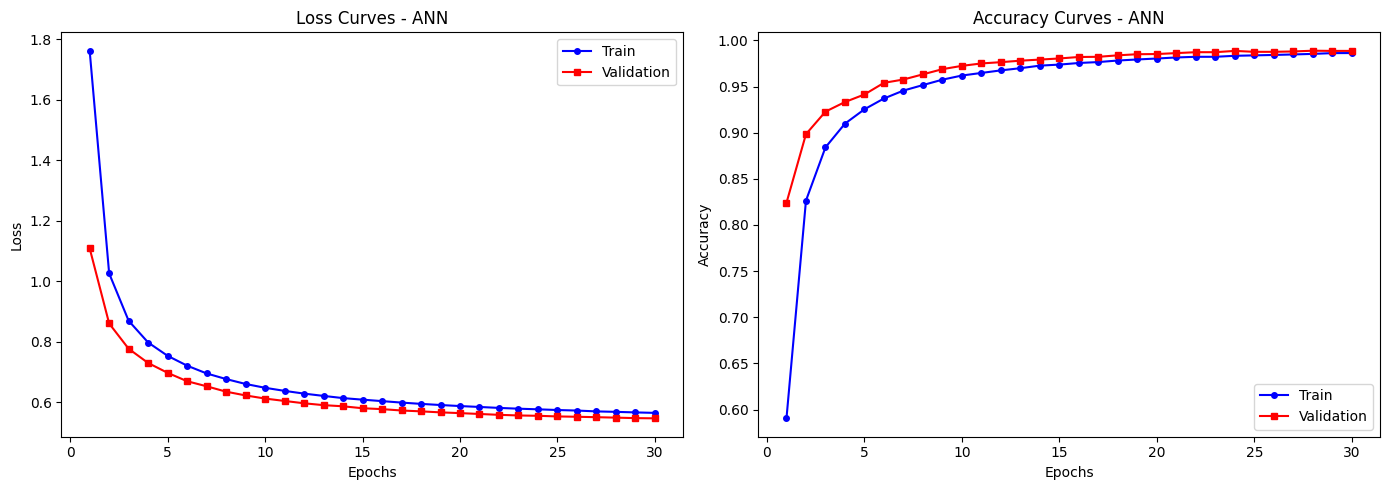


───────────────────────────────────────────────────────
  ANN
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    0 - zero      0.970     0.993     0.981       451
     1 - one      0.996     1.000     0.998       553
     2 - two      0.986     0.988     0.987       495
   3 - three      0.985     0.992     0.989       530
    4 - four      0.988     0.990     0.989       501
    5 - five      0.996     0.989     0.992       449
     6 - six      0.991     0.974     0.982       460
   7 - seven      0.976     0.989     0.982       531
   8 - eight      0.990     0.982     0.986       508
    9 - nine      0.986     0.966     0.976       522

    accuracy                          0.986      5000
   macro avg      0.986     0.986     0.986      5000
weighted avg      0.986     0.986     0.986      5000

  Macro F1: 0.9863

  Confusion Matrix: tensor([[448,   0,   0,   0,   0,   0,   1,   1,   1,   0],
        [  0, 553,   0

In [22]:
ANN_MODELS = {
    'ANN': (ANN(NUM_CLASSES), False),
    # 'ANNV2': (ANNV2(), False),
}

history_results_adam_w, evaluation_results_adam_w, results_adam_w = start_training_loop_adam_w(
    ANN_MODELS, train_dataloader,  a_val_dataloader, a_test_dataloader
)

In [23]:
ANN_RESULTS = results_adam_w


  Confusion Matrix: ANN


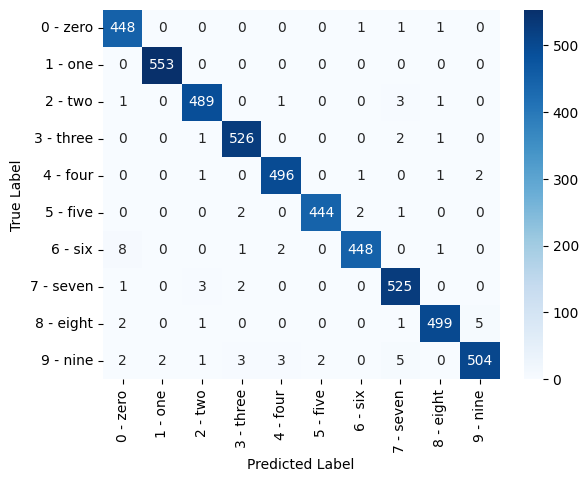

In [24]:
for model_name, er in evaluation_results_adam_w.items():
  print(f"\n{'='*60}")
  print(f"  Confusion Matrix: {model_name}")
  print(f"{'='*60}")
  plot_confusion_matrix(er, model_name)


In [25]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict_(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()


def predict(model, image, device):
    model.eval()

    # NumPy -> Tensor if necessary
    if isinstance(image, np.ndarray):
        image = torch.from_numpy(image)

    image = image.float()

    # (C, H, W) -> (1, C, H, W)
    if image.ndim == 3:
        image = image.unsqueeze(0)

    # (H, W) -> (1, 1, H, W)
    elif image.ndim == 2:
        image = image.unsqueeze(0).unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)

    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names, real_class):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))

    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    axarr[0].set_title(f"Real Class: {real_class}")

    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()


# Visualization
def visualize_predictions_colored(original_image, probabilities, class_names, real_class):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))

    # --------------------------------------------------
    # Prepare image for matplotlib
    # --------------------------------------------------
    if isinstance(original_image, torch.Tensor):
        original_image = original_image.detach().cpu().squeeze().numpy()
    else:
        original_image = np.asarray(original_image).squeeze()

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------
    max_idx = np.argmax(probabilities)
    predicted_class = class_names[max_idx]

    is_correct = predicted_class == real_class
    title_color = "green" if is_correct else "red"

    # --------------------------------------------------
    # Left: Image
    # --------------------------------------------------
    axarr[0].imshow(original_image, cmap="gray")
    axarr[0].axis("off")

    axarr[0].set_title(
        f"Real: {real_class}\nPredicted: {predicted_class}",
        color=title_color,
        fontsize=14,
        fontweight="bold"
    )

    # --------------------------------------------------
    # Right: Bar chart
    # --------------------------------------------------
    bar_colors = []

    for i, cls in enumerate(class_names):
        prob = probabilities[i]

        if prob == 0:
            bar_colors.append("lightgray")

        elif cls == predicted_class:
            if predicted_class == real_class:
                bar_colors.append("green")
            else:
                bar_colors.append("red")

        elif cls == real_class:
            bar_colors.append("green")

        else:
            bar_colors.append("pink")

    bars = axarr[1].barh(
        class_names,
        probabilities,
        color=bar_colors
    )

    # Color y-axis labels
    for label in axarr[1].get_yticklabels():
        cls = label.get_text()

        if cls == real_class:
            label.set_color("green")
            label.set_fontweight("bold")

        elif cls == predicted_class and predicted_class != real_class:
            label.set_color("red")
            label.set_fontweight("bold")

    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    # Show probability values
    for bar, prob in zip(bars, probabilities):
        axarr[1].text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{prob:.2f}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


def test_model(model, examples, transforms=None):
    for example in test_examples:
        original_image, image_tensor = preprocess_image(example, transforms)
        probabilities = predict(model, image_tensor, DEVICE)

        # Assuming dataset.classes gives the class names
        class_names = dataset.classes
        visualize_predictions_colored(original_image, probabilities, class_names, Path(example).parent.name)




#best_model = get_model_from_model_name(best_name)
best_model, _ = ANN_MODELS['ANN']
best_model.to(DEVICE)



ANN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)

Original image
label: 3


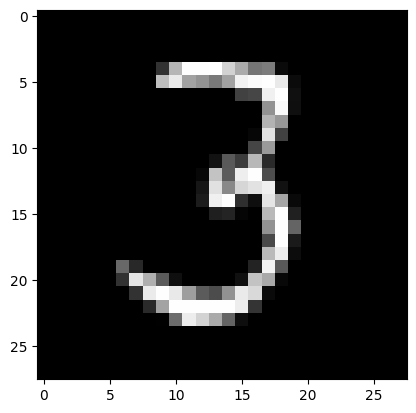

In [26]:
# Load a single image from the test set
index = 4373
input, label = a_test_dataset[index]
#input = torchvision.transforms.ToPILImage()(input)
#plt.imshow(input)
plt.imshow(input.squeeze().detach().cpu().numpy(), cmap="gray")
print('Original image')
print(f"label: {label}")
plt.show()

In [27]:
(a_test_dataset, a_test_dataset.dataset.classes)

(<torch.utils.data.dataset.Subset at 0x7f9e85fbc910>,
 ['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'])

In [28]:
input, label = a_test_dataset[index]
label

3

True label: 3
Predicted label: 3


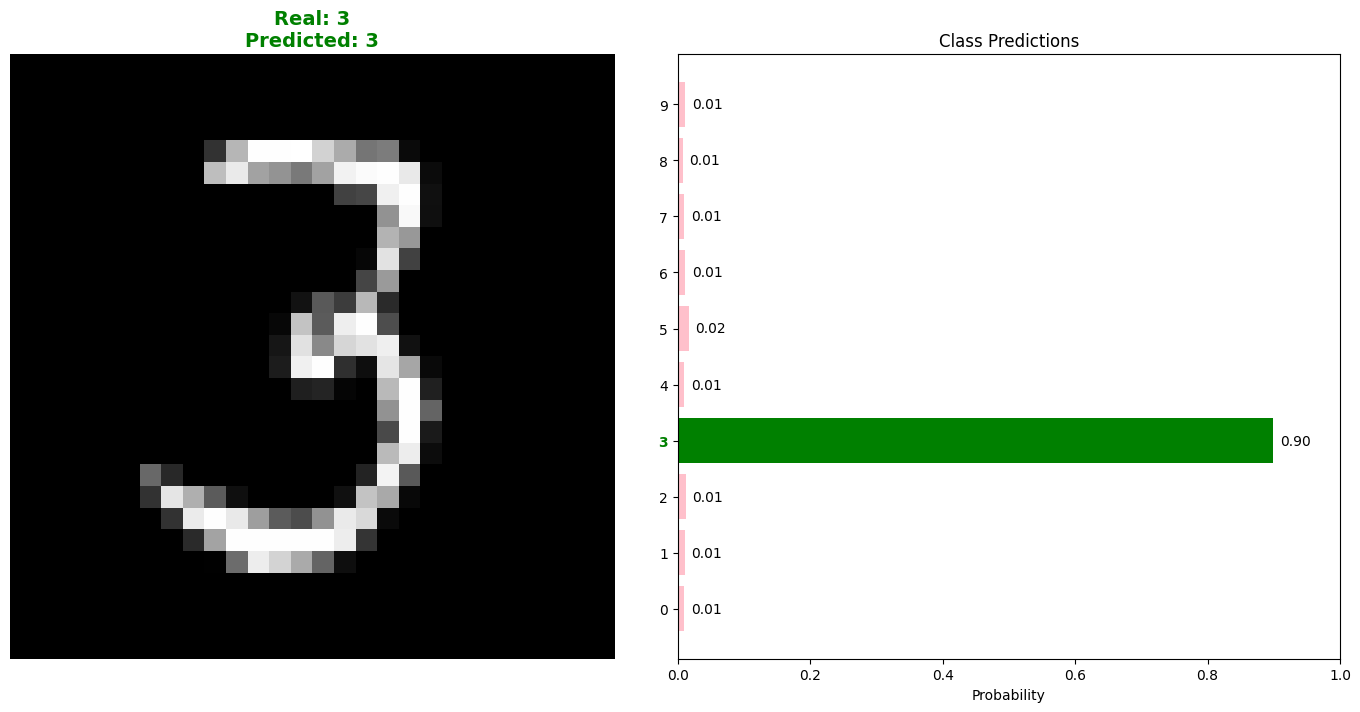

In [29]:
# Load a single image
index = 4373  # must be < 5000 if using your split test_dataset
input, label = a_test_dataset[index]

# Keep tensor shape: (1, 28, 28)
image_tensor = input

probabilities = predict(best_model, image_tensor, DEVICE)

print(f"True label: {label}")
print(f"Predicted label: {probabilities.argmax()}")

class_names = [str(i) for i in range(10)]# a_test_dataset.dataset.classes
visualize_predictions_colored(
    input,
    probabilities,
    class_names,
    str(label)
)

# SNN

In [30]:
from spikingjelly.activation_based import neuron, layer, functional, surrogate, encoding
import torch.nn as nn

class DirectSNN(nn.Module):
    """Same topology as the ANN: 2×Conv+Pool -> FC 512 -> FC 256 -> FC 10.
    ReLU replaced by LIF; dropout omitted (or use layer.Dropout)."""

    def __init__(self, num_classes=10, tau=2.0):
        super().__init__()
        surr = surrogate.ATan()

        self.features = nn.Sequential(
            # Block 1  (matches ANN: 32 filters, 3×3, pool/2)
            layer.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),
            layer.MaxPool2d(kernel_size=2),   # 28 -> 14

            # Block 2  (matches ANN: 64 filters, 3×3, pool/2)
            layer.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),
            layer.MaxPool2d(kernel_size=2),   # 14 -> 7
        )

        self.classifier = nn.Sequential(
            layer.Flatten(),
            # 64 * 7 * 7 = 3136  (for 28×28 input)
            layer.Linear(64 * 7 * 7, 512, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),
            # optional: layer.Dropout(0.4)
            layer.Linear(512, 256, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),
            layer.Linear(256, num_classes, bias=False),
            neuron.LIFNode(tau=tau, surrogate_function=surr),  # output spikes
        )

    def forward(self, x):
        # x: [N, 1, 28, 28]  or already spikes from encoder
        x = self.features(x)
        x = self.classifier(x)
        return x

In [31]:
# Define network architecture
class SNN(nn.Module):
    def __init__(self):
        super(SNN, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_1 = nn.Linear(in_features=28 * 28, out_features=10, bias=False)
        self.lif_layer_1 = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear_1(x)
        x = self.lif_layer_1(x)
        # x = F.softmax(x, dim=0) #softmax activation layer is used for multivariate classification
        return x

# Instantiate neural network
snn = DirectSNN()
snn = snn.to(device) # Convert neural network

# Print neural network information
print ("Spiking Neural network information")
print(snn)

# Test the output format of the neural network
# Set the input that meets the requirements
input = torch.ones([1, 1, 28, 28])
input = input.to(device)
print ("Input data format", input.shape)

output = snn(input)
print ("Output data format", output.shape)

# View the size of the neural network model
summary(snn, input_size=[[1, 28, 28]])

# After optimizing the parameters once, you need to reset the state of the network, because SNN neurons have "memory”
functional.reset_net(snn)

Spiking Neural network information
DirectSNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (1): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (4): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1, step_mode=s)
    (1): Linear(in_features=3136, out_features=512, bias=False)
    (2): LIFNode(
      v_threshold=

In [32]:
# Set neural network hyperparameters
# Set the loss function
loss_fn = nn.CrossEntropyLoss()
loss_fn= loss_fn.to (device) # Convert the loss function

# Set up optimizer
learning_rate = 0.001 # Set the learning rate
lambda_val = 0.0 # Set the regularization coefficient Lambda
optim = torch.optim.AdamW(snn.parameters(), lr=learning_rate, weight_decay=lambda_val)

# Define input data encoder
encoder = encoding.PoissonEncoder()

# Set the simulation time T
T = 20

In [33]:
# Set the number of training rounds epoch and define the temporary parameters required during the training process
# Set the number of training rounds
epoch = 5
# Define the training set loss and accuracy variables
loss_train = 0.0 # Training loss value
loss_train_sum = 0.0 # Cumulative value of training loss value
loss_train_mean = 0.0 # The average value of the loss value of this round of training
loss_train_store = np.zeros(epoch) # Training loss value storage array
accuracy_train = 0 # Training accuracy
accuracy_rate_train = 0.0 # Training accuracy
accuracy_rate_train_max = 0.0 # Maximum training accuracy
accuracy_rate_train_store = np.zeros(epoch) # Training accuracy storage prime array
# Define cross-verification set loss and accuracy variables
loss_cv = 0.0 # Verify the loss value
loss_cv_sum = 0.0 # Verify the cumulative value of the loss value
loss_cv_mean = 0.0 # The average value of the loss value in this round of verification
loss_cv_store = np.zeros(epoch) # Verification loss value storage array
accuracy_cv = 0 # Verify the exact number
accuracy_rate_cv = 0.0 # Verification accuracy
accuracy_rate_cv_max = 0.0 # Maximum verification accuracy
accuracy_rate_cv_store = np.zeros(epoch) # Verify the accuracy of the stored prime array

In [34]:
# Training network

#########################Start training########################

for i in range(epoch):
    print("----------- %d round of training begins------------" % i)
    # The accumulated value of each round of loss is cleared to zero
    loss_train_sum = 0
    loss_cv_sum = 0
    # Start training neural network
    snn.train()
    # This round of training counts
    train_step = 0
    # Accuracy variable cleared
    accuracy_train = 0
    for data in train_dataloader:
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        label_onehot = F.one_hot(labels, 10).float() # Convert tags to independent thermal coding

        out_fr = 0. # Output neuron pulse emission rate
        #out_fr is the tensor of shape=[batch_size, 10]
        # Record the pulse emission rate of 10 neurons in the output layer during the entire simulation time
        for t in range(T):
            encoded_img = encoder(inputs) #First encode the input image into pulse data
            out_fr+=snn(encoded_img) # Accumulate the pulse output of 10 neurons in the output layer
        out_fr = out_fr /T # Divide by time to obtain the pulse emission rate of 10 neurons in the output layer
        # Calculate the loss function
        loss_train = F.mse_loss(out_fr, label_onehot)
        # The loss function is the pulse emission frequency of neurons in the output layer, which is the same as the MSE of the real category
        # Such a loss function will make: when the label i is given, the pulse emission frequency of the i-th neuron in the output layer approaches 1, while the pulse emission frequency of other neurons approaches 0
        # Cumulative loss function
        loss_train_sum += loss_train.item()
        # Convert the classification probability into the corresponding label
        pred_label = out_fr.argmax(1)
        # Accuracy of cumulative calculation results
        accuracy_train += (pred_label == labels).sum()
        # Clear the cumulative gradient of the optimizer
        optim.zero_grad()
        # Calculate gradient
        loss_train.backward()
        # The optimizer starts to optimize
        optim.step()

        # After optimizing the parameters once, you need to reset the state of the network, because SNN neurons have "memory”
        functional.reset_net(snn)

    # Calculate the average training set loss
    loss_train_mean = loss_train_sum / (train_dataset_size / batch_size)
    loss_train_store[i] = loss_train_mean # Store the loss for plotting the loss curve later
    # Calculate training set accuracy
    accuracy_rate_train = (accuracy_train / train_dataset_size) * 100
    accuracy_rate_train_store[i] = accuracy_rate_train


    # Start testing the neural network
    snn.eval()
    # Test step counter for this round
    test_step = 0
    # Reset the accuracy variable
    accuracy_cv = 0
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)
            label_onehot = F.one_hot(labels, 10).float()
            out_fr = 0.0
            for t in range(T):
                encoded_img = encoder(inputs)
                # Feed into the neural network and run
                out_fr += snn(encoded_img)
            out_fr = out_fr / T
            # Compute the loss function
            loss_cv = F.mse_loss(out_fr, label_onehot)
            # Accumulate the loss function
            loss_cv_sum += loss_cv.item()
            # Convert the classification probability to the corresponding label
            pred_label = out_fr.argmax(1)
            # Accumulate accuracy
            accuracy_cv += (pred_label == labels).sum()
            test_step += 1
            # After each parameter optimization, the network’s state must be reset because SNN neurons have “memory”
            functional.reset_net(snn)

        # Calculate the cross-validation set loss (loss_cv)
        loss_cv_mean = loss_cv_sum / (test_dataset_size / batch_size)
        loss_cv_store[i] = loss_cv_mean # Record the loss for later plotting of the loss curve
        # Calculate the cross-validation accuracy
        accuracy_rate_cv = (accuracy_cv / test_dataset_size) * 100
        accuracy_rate_cv_store[i] = accuracy_rate_cv

    # Print the results of this training round
    print(f"loss train: {loss_train_mean: .4f}, accuracy rate train: {accuracy_rate_train.item(): .4f}%, loss cv: {loss_cv_mean: .4f}, accuracy rate cv: {accuracy_rate_cv.item(): .4f}%")
    # Automatically save neural network models whose accuracy during training exceeds that of previous models

    if (accuracy_rate_train + accuracy_rate_cv > accuracy_rate_train_max + accuracy_rate_cv_max):
        torch.save(snn, model_auto_save_dir + "model_auto_save_acc%d.pth" %accuracy_rate_cv)
        accuracy_rate_train_max = accuracy_rate_train  # Record the maximum training accuracy
        accuracy_rate_cv_max = accuracy_rate_cv  # Record the maximum validation accuracy

######################### End of Training########################
print('-------------------------------Training Complete-------------------------------')

----------- 0 round of training begins------------
loss train:  0.0223, accuracy rate train:  82.6217%, loss cv:  0.0039, accuracy rate cv:  97.7600%
----------- 1 round of training begins------------
loss train:  0.0030, accuracy rate train:  98.2533%, loss cv:  0.0022, accuracy rate cv:  98.5900%
----------- 2 round of training begins------------
loss train:  0.0019, accuracy rate train:  98.8900%, loss cv:  0.0022, accuracy rate cv:  98.6800%
----------- 3 round of training begins------------
loss train:  0.0015, accuracy rate train:  99.1167%, loss cv:  0.0018, accuracy rate cv:  98.8200%
----------- 4 round of training begins------------
loss train:  0.0012, accuracy rate train:  99.3417%, loss cv:  0.0017, accuracy rate cv:  98.9300%
-------------------------------Training Complete-------------------------------


---------Graph showing how the loss function changes over training epochs---------


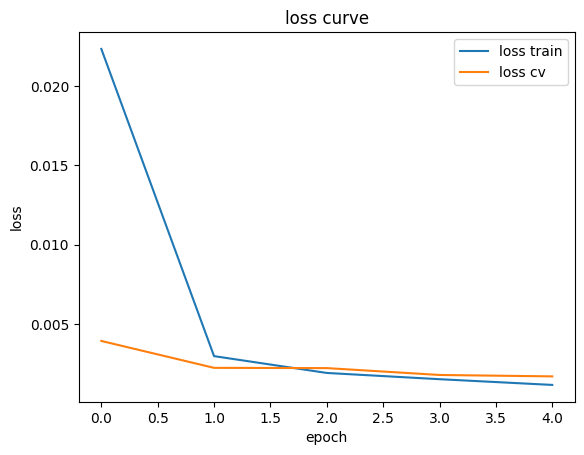

---------Graph showing how accuracy changes over training epochs---------


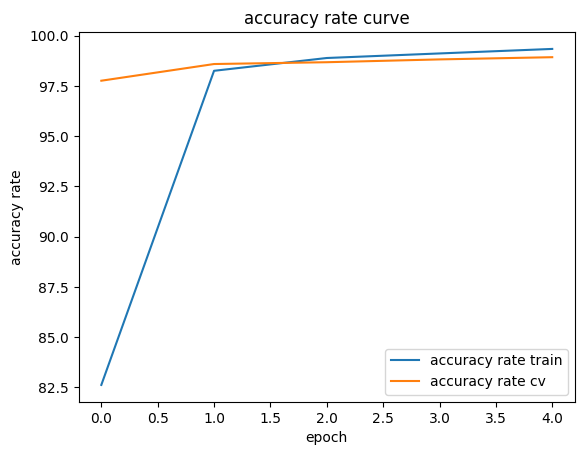

In [35]:
# Plot the loss curve
print('---------Graph showing how the loss function changes over training epochs---------')
plt.plot(np.arange(epoch), loss_train_store, np.arange(epoch), loss_cv_store)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(["loss train", 'loss cv'])
plt.title('loss curve')
plt.show()

# Plot the accuracy curve
print('---------Graph showing how accuracy changes over training epochs---------')
plt.plot(np.arange(epoch), accuracy_rate_train_store, np.arange(epoch), accuracy_rate_cv_store)
plt.xlabel('epoch')
plt.ylabel('accuracy rate')
plt.legend(["accuracy rate train", "accuracy rate cv"])
plt.title('accuracy rate curve')
plt.show()

In [36]:
# Next, let’s run the inference process separately and output the results every 100 iterations.
# Load a model from a specific training round for prediction
# net = torch.load(“model_save/auto_save/model_auto_save_acc95.pth”)
# net = torch.load(“module_save/history_save/module_save_acc63.pth”)

# Start making predictions with the neural network
snn.eval()
# Total number of test steps
test_step = 0
# Track accuracy
accuracy = 0
with torch.no_grad(): # No gradient descent during the prediction phase
    for data in test_dataloader:
        inputs, labels = data
        inputs = inputs.to(device) # Convert the data
        labels = labels.to(device) # Convert data
        label_onehot = F.one_hot(labels, 10).float()
        out_fr = 0.0
        for t in range(T):
            encoded_img = encoder(inputs)
            out_fr += snn(encoded_img)
        out_fr = out_fr / T
        # Convert classification probabilities to corresponding labels
        pred_label = out_fr.argmax(1)
        # Output results every 100 iterations
        if (test_step % 100 == 0):
            print('Output result', pred_label)
            print('Original labels', labels)
        # Accumulate accuracy
        accuracy += (pred_label == labels).sum()
        test_step += 1

        # After each parameter optimization, the network’s state must be reset because SNN neurons have “memory”
        functional.reset_net(snn)

accuracy_rate = accuracy / test_dataset_size
print('Number of correct predictions:', accuracy.item(), 'Total test cases:', test_dataset_size)
print("Model accuracy: %.2f%%" % (accuracy_rate.item() * 100))


Output result tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3], device='cuda:0')
Original labels tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3], device='cuda:0')
Output result tensor([0, 9, 6, 8, 8, 5, 6, 1, 1, 9, 8, 9, 2, 3, 5, 5, 9, 4, 2, 1, 9, 3, 9, 2,
        0, 6, 0, 4, 0, 0, 1, 2, 3, 4, 7, 8, 9, 0, 1, 2, 3, 7, 8, 9, 0, 1, 2, 3,
        4, 7, 8, 9, 7, 3, 0, 3, 1, 8, 7, 6, 4, 0, 2, 6], device='cuda:0')
Original labels tensor([0, 9, 6, 8, 8, 5, 6, 1, 1, 9, 8, 9, 2, 3, 5, 5, 9, 4, 2, 1, 9, 3, 9, 2,
        0, 6, 0, 4, 0, 0, 1, 2, 3, 4, 7, 8, 9, 0, 1, 2, 3, 7, 8, 9, 0, 1, 2, 3,
        4, 7, 8, 9, 7, 3, 0, 3, 1, 8, 7, 6, 4, 0, 2, 6], device='cuda:0')
Numb

Original image
label: 7


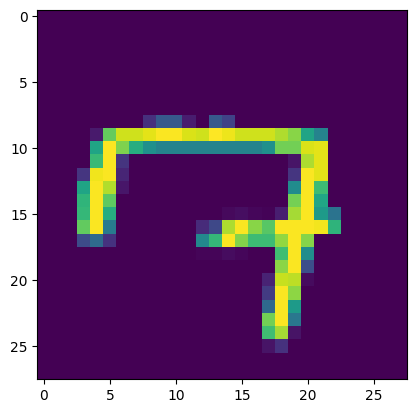

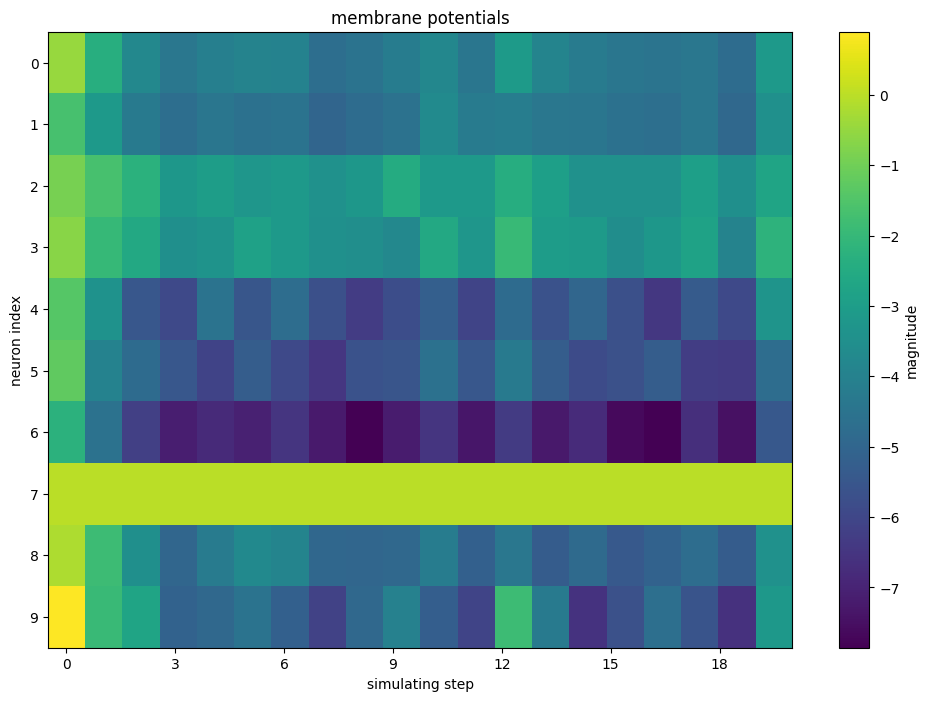

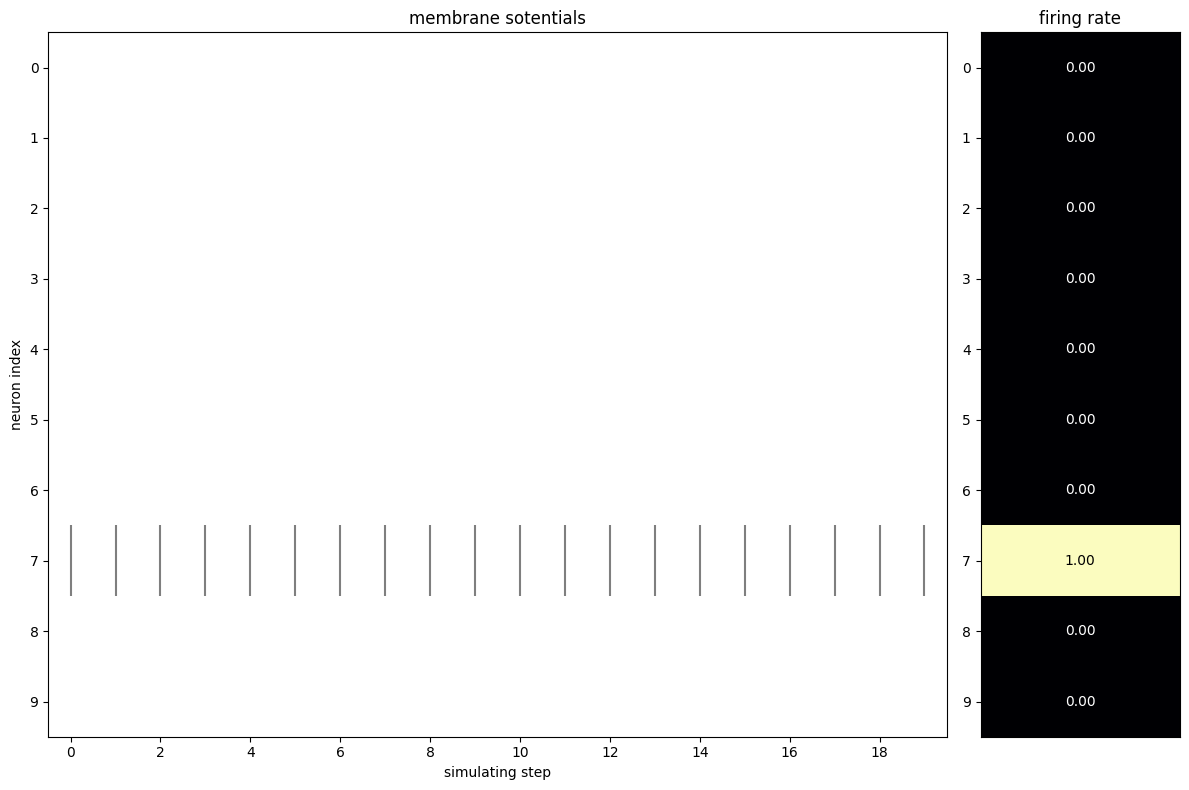

In [37]:
#For a more intuitive understanding, we can select a single image for prediction; by changing the index, we can choose different input images.

# Obtaining the membrane potential of the output layer neurons at this point is somewhat challenging and requires the use of the “hook” feature.

# Retrieve a single image for prediction

# Load the raw data
# Load a single image from the test set
# Save the data for plotting
snn.eval()
# Register a hook
output_layer = snn.classifier[6] # snn.lif_layer_1 # Output layer
output_layer.v_seq = []
output_layer.s_seq = []
def save_hook(m, x, y):
    m.v_seq.append(m.v.unsqueeze(0))
    m.s_seq.append(y.unsqueeze(0))

hook = output_layer.register_forward_hook(save_hook)

# Load a single image from the test set
index = 3373
input, label = test_dataset[index]
input = torchvision.transforms.ToPILImage()(input)
plt.imshow(input)
print('Original image')
print(f"label: {label}")
plt.show()

# Start making predictions with the neural network
snn.eval()
with torch.no_grad():
    img, label = test_dataset[index]
    # img = img.to(device)
    img = img.unsqueeze(0).to(device) # for DirectSNN
    out_fr = 0.
    for t in range(T):
        encoded_img = encoder(img)
        out_fr += snn(encoded_img)
    out_spikes_counter_frequency = (out_fr / T).cpu().numpy()

    output_layer.v_seq = torch.cat(output_layer.v_seq)
    output_layer.s_seq = torch.cat(output_layer.s_seq)
    v_t_array = output_layer.v_seq.cpu().numpy().squeeze()  # v_t_array[i][j] represents the voltage value of neuron i at time j
    s_t_array = output_layer.s_seq.cpu().numpy().squeeze()  # s_t_array[i][j] represents the spike fired by neuron i at time j, which is either 0 or 1

    # Heatmap of membrane potentials and spike output results
    figsize = (12, 8)
    dpi = 100
    visualizing.plot_2d_heatmap(array=v_t_array, title='membrane potentials', xlabel='simulating step',
                                ylabel='neuron index', int_x_ticks=True, x_max=T, figsize=figsize, dpi=dpi)
    visualizing.plot_1d_spikes(spikes=s_t_array, title='membrane sotentials', xlabel='simulating step',
                            ylabel='neuron index', figsize=figsize, dpi=dpi)

    plt.show()

hook.remove()

In [38]:
# Save the spiking neural network model
torch.save(snn, model_history_save_dir + "module_save_acc.pth")
print('Model saved')

Model saved


In [39]:
# View spiking network parameters
print(snn)
snn.named_parameters()
for name, param in snn.named_parameters(prefix="SNN"):
    print(name, param)
    print(name, param.size())

DirectSNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (1): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (4): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1, step_mode=s)
    (1): Linear(in_features=3136, out_features=512, bias=False)
    (2): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=Fals

# ANN2SNN

## Conversion

In [40]:
import spikingjelly.activation_based.ann2snn as ann2snn
import inspect

print("=== ann2snn ===")
print(dir(ann2snn))

print("\n=== converter ===")
print(dir(ann2snn.converter))

print("\n=== modules ===")
print(dir(ann2snn.modules))

print("\n=== utils ===")
print(dir(ann2snn.utils))


=== ann2snn ===
['ChannelVoltageScaler', 'ConversionRecipe', 'Converter', 'FXConversionRecipe', 'FXConverter', 'LocalThresholdBalancingRecipe', 'ModuleConversionRecipe', 'ModuleConverter', 'Qwen2SNNCalibration', 'Qwen2SNNConfig', 'Qwen2SNNModel', 'Qwen2SNNRecipe', 'RateCodingRecipe', 'STATransformerRecipe', 'SignedQCFSSequenceEncoder', 'SpikeZIPTFQANNRecipe', 'TransformerTDEquivalentRecipe', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'calibrate_qwen2_snn', 'converter', 'delay', 'download_url', 'estimate_delay_start', 'modules', 'operators', 'qcfs', 'recipes', 'utils']

=== converter ===
['Converter', 'FXConversionRecipe', 'FXConverter', 'ModuleConversionRecipe', 'ModuleConverter', 'Optional', 'TransformerTDEquivalentRecipe', 'Union', '_FX_TRACE_LOCK', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_resolve_device', '_symbolic_trace', 'fx', 'l

In [41]:
torch.random.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
#dataset_dir = "./data/mnist"
batch_size = 100
TT = 50

In [42]:
calibration_data_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=False, drop_last=False
)


In [43]:
from spikingjelly.activation_based import ann2snn

recipe = ann2snn.RateCodingRecipe(
    dataloader=calibration_data_loader,
    mode="max",
)
conv_snn_max = ann2snn.FXConverter(recipe).convert(best_model)

100%|██████████| 600/600 [00:08<00:00, 74.58it/s]


In [44]:
recipe = ann2snn.RateCodingRecipe(
    dataloader=calibration_data_loader,
    mode="99.9%",
)
conv_snn_99 = ann2snn.FXConverter(recipe).convert(best_model)

100%|██████████| 600/600 [00:09<00:00, 66.58it/s]


## Accuracy vs Timesteps

In [ ]:
@torch.no_grad()
def accuracy_vs_T_(model, loader, T_max, device):
    model.eval()
    correct = torch.zeros(T_max); total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        functional.reset_net(model)
        acc, preds = 0., []
        for t in range(T_max):
            acc = acc + model(x)
            preds.append(acc.argmax(1))          # prediction using spikes up to t
        for t in range(T_max):
            correct[t] += (preds[t] == y).sum().item()
        total += y.size(0)
    return (100.0 * correct / total).tolist()

# curve = accuracy_vs_T_(snn, a_test_dataloader, T_max=64, device=device)
# plot curve against range(1, 65): x=timesteps (latency), y=accuracy

curve_max  = accuracy_vs_T_(conv_snn_max,  a_test_dataloader, T_max=64, device=device)
curve_99 = accuracy_vs_T_(conv_snn_99, a_test_dataloader, T_max=64, device=device)
curve_base_snn = accuracy_vs_T_(snn, a_test_dataloader, T_max=64, device=device)

## Plot Trace Neuron

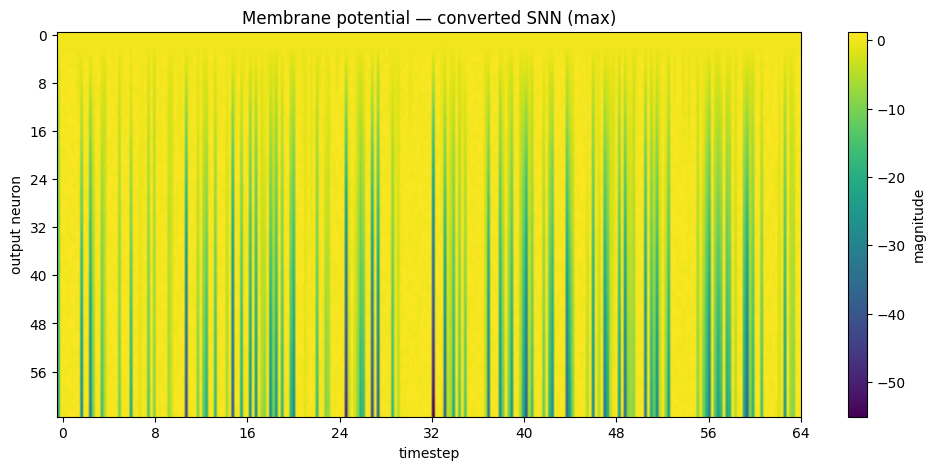

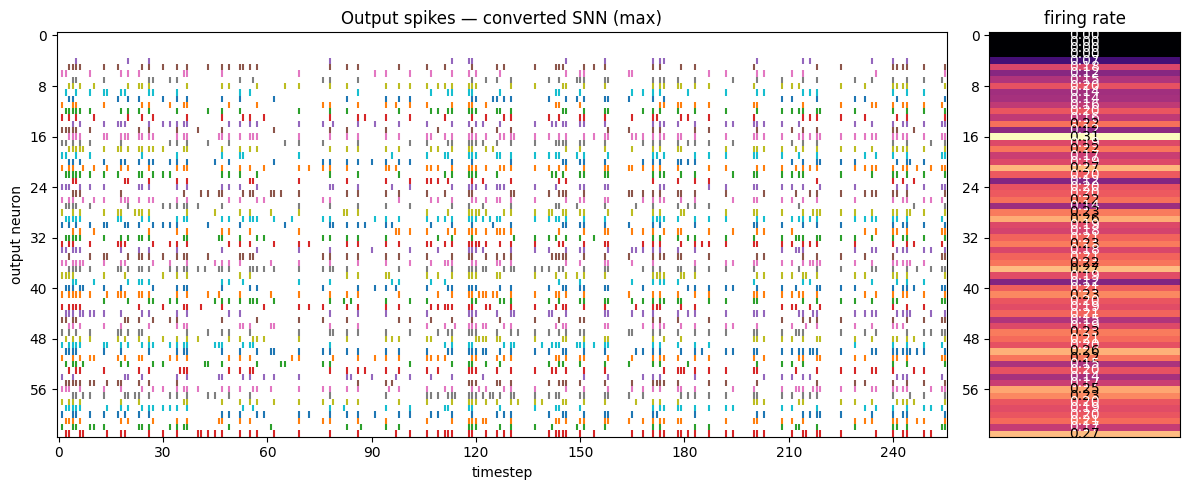

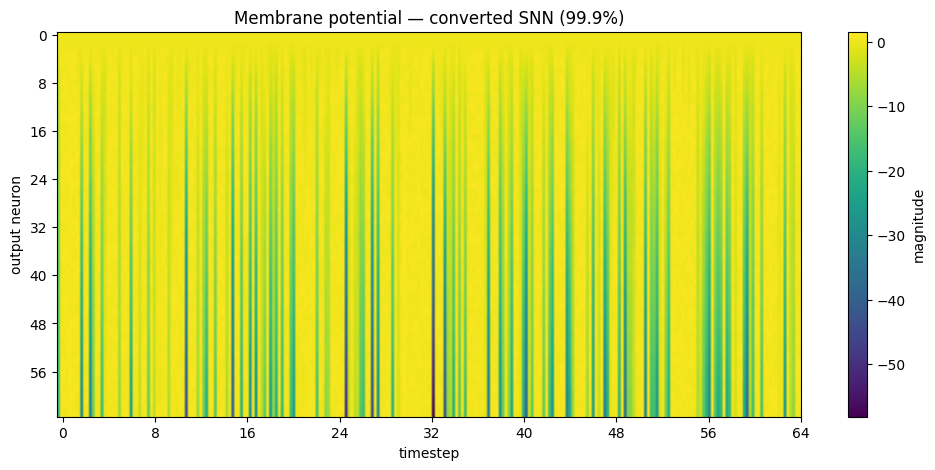

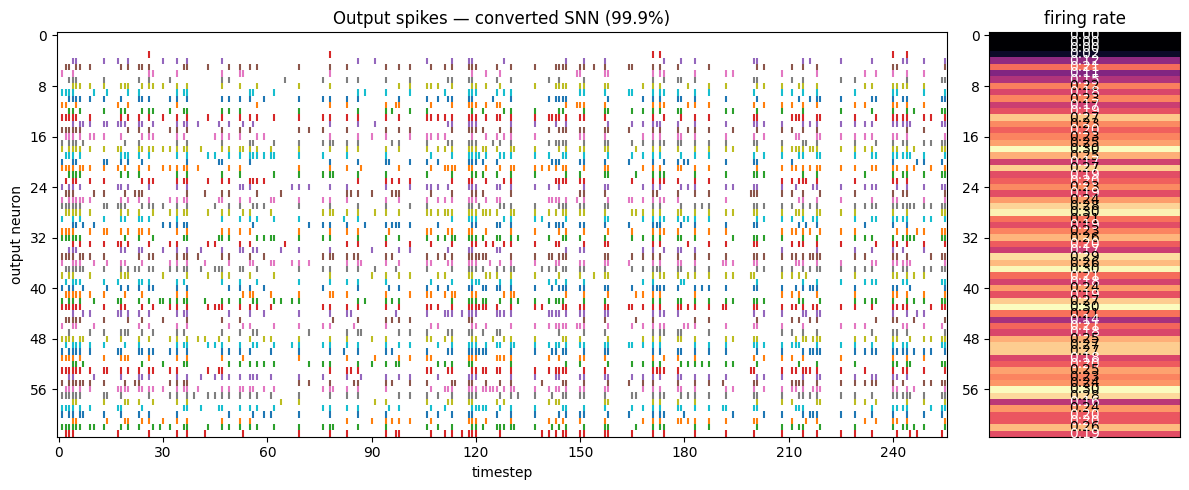

In [46]:

def trace_neuron(model, node, img, T, device):
    """Record membrane potential v and spikes of one IF node over T steps."""
    model = model.to(device).eval()
    v_seq, s_seq = [], []

    def hook(m, x, y):
        v_seq.append(m.v.detach().float().cpu().unsqueeze(0))   # membrane BEFORE reset
        s_seq.append(y.detach().float().cpu().unsqueeze(0))     # output spikes (0/1)

    h = node.register_forward_hook(hook)
    functional.reset_net(model)
    with torch.no_grad():
        x = img.unsqueeze(0).to(device)      # [1,1,28,28] — converted model takes analog input
        for _ in range(T):
            model(x)                            # feed analog image each step; IF accumulates
    functional.reset_net(model)
    h.remove()

    v = torch.cat(v_seq).numpy().squeeze()    # [T, n_neurons]
    s = torch.cat(s_seq).numpy().squeeze()
    return v.T, s.T                           # transpose -> [neuron, step] for the plotters


# grab the final spiking layer of each converted model
node_max = conv_snn_max.get_submodule("classifier.spiking_1.if_node")
node_99  = conv_snn_99.get_submodule("classifier.spiking_1.if_node")

img, label = a_test_dataset[3373]
T = 64

for tag, s_net, node in [("max", conv_snn_max, node_max), ("99.9%", conv_snn_99, node_99)]:
    v_arr, s_arr = trace_neuron(s_net, node, img, T, device)
    visualizing.plot_2d_heatmap(array=v_arr, title=f"Membrane potential — converted SNN ({tag})",
                                xlabel="timestep", ylabel="output neuron",
                                int_x_ticks=True, x_max=T, figsize=(12, 5), dpi=100)
    visualizing.plot_1d_spikes(spikes=s_arr, title=f"Output spikes — converted SNN ({tag})",
                               xlabel="timestep", ylabel="output neuron", figsize=(12, 5), dpi=100)
    plt.show()

In [47]:
def try_visualize_converted(model, dataset, T, index=3373, device='cuda'):
    model.eval()
    functional.reset_net(model)

    # Locate the last IFNode that produces the 10-class spikes
    # (for the structure you printed it is classifier.spiking_1.if_node)
    output_neuron = None
    for name, module in model.named_modules():
        if isinstance(module, neuron.IFNode) or isinstance(module, neuron.LIFNode):
            output_neuron = module   # keep the last one we encounter
    if output_neuron is None:
        raise RuntimeError("No IFNode / LIFNode found in the model")

    # Storage for membrane potential and spikes
    output_neuron.v_seq = []
    output_neuron.s_seq = []

    def save_hook(m, x, y):
        # m.v is the membrane potential *after* the current step
        # y is the spike tensor
        output_neuron.v_seq.append(m.v.detach().unsqueeze(0))
        output_neuron.s_seq.append(y.detach().unsqueeze(0))

    hook = output_neuron.register_forward_hook(save_hook)

    # Load one sample
    img, label = dataset[index]
    print(f"Original label: {label}")
    plt.imshow(torchvision.transforms.ToPILImage()(img), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

    with torch.no_grad():
        x = img.unsqueeze(0).to(device)          # [1, 1, 28, 28]
        out_fr = 0.
        for t in range(T):
            out_fr += model(x)                   # rate-coding style accumulation
        out_fr = out_fr / T
        pred = out_fr.argmax(1).item()
        print(f"Predicted class (rate coding, T={T}): {pred}")

        # Concatenate recorded sequences
        if len(output_neuron.v_seq) == 0:
            raise RuntimeError("Hook collected no data – check that the correct neuron was selected")
        v_t_array = torch.cat(output_neuron.v_seq).cpu().numpy().squeeze()  # [T, 10]
        s_t_array = torch.cat(output_neuron.s_seq).cpu().numpy().squeeze()  # [T, 10]

        # Visualise
        figsize = (12, 8)
        dpi = 100
        visualizing.plot_2d_heatmap(
            array=v_t_array,
            title='Membrane potentials (output layer)',
            xlabel='simulating step',
            ylabel='neuron index',
            int_x_ticks=True,
            x_max=T,
            figsize=figsize,
            dpi=dpi
        )
        visualizing.plot_1d_spikes(
            spikes=s_t_array,
            title='Output spikes',
            xlabel='simulating step',
            ylabel='neuron index',
            figsize=figsize,
            dpi=dpi
        )
        plt.show()

    hook.remove()
    functional.reset_net(model)

Original label: 7


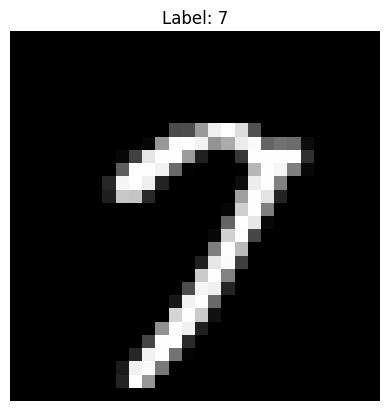

Predicted class (rate coding, T=16): 7


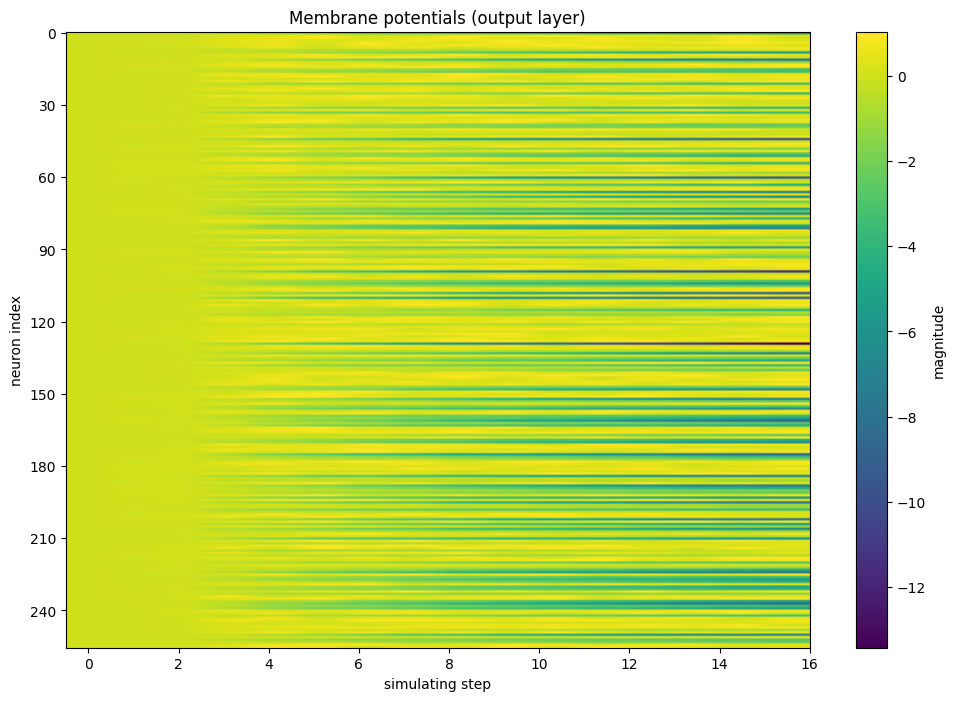

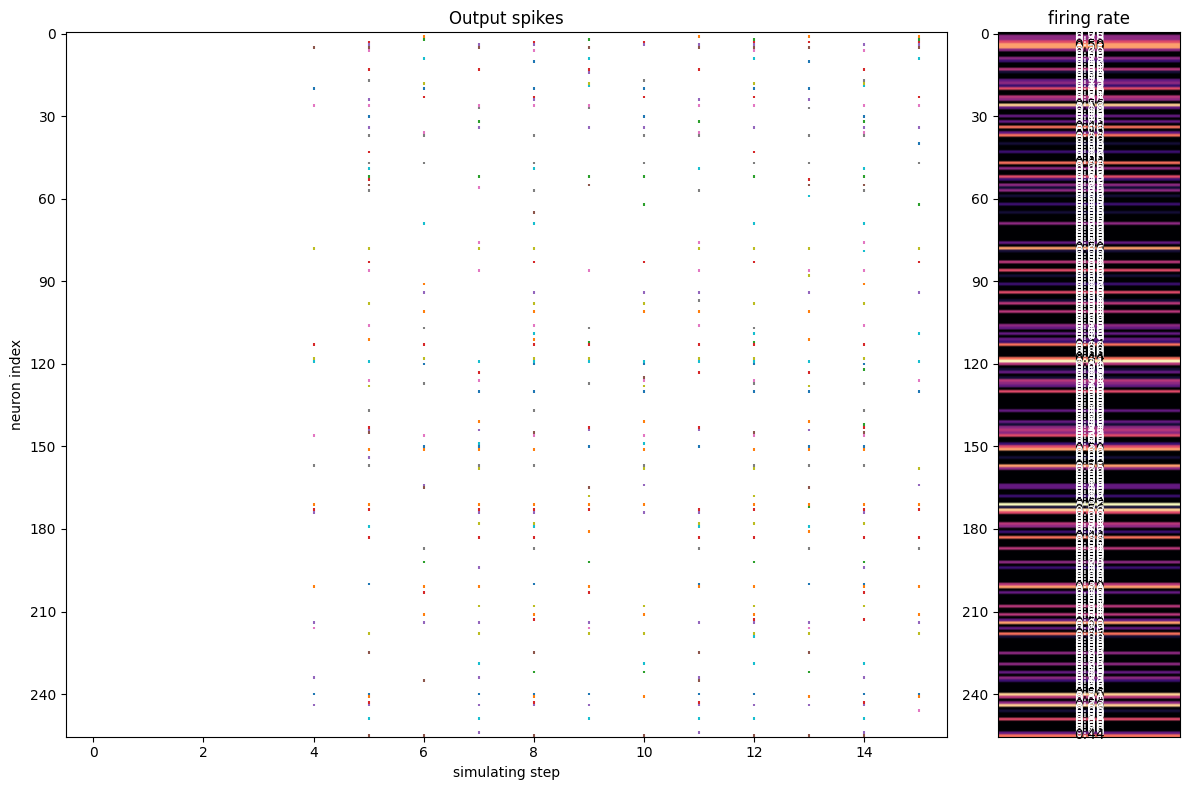

Original label: 7


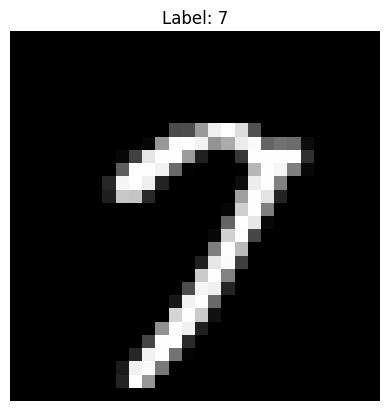

Predicted class (rate coding, T=16): 7


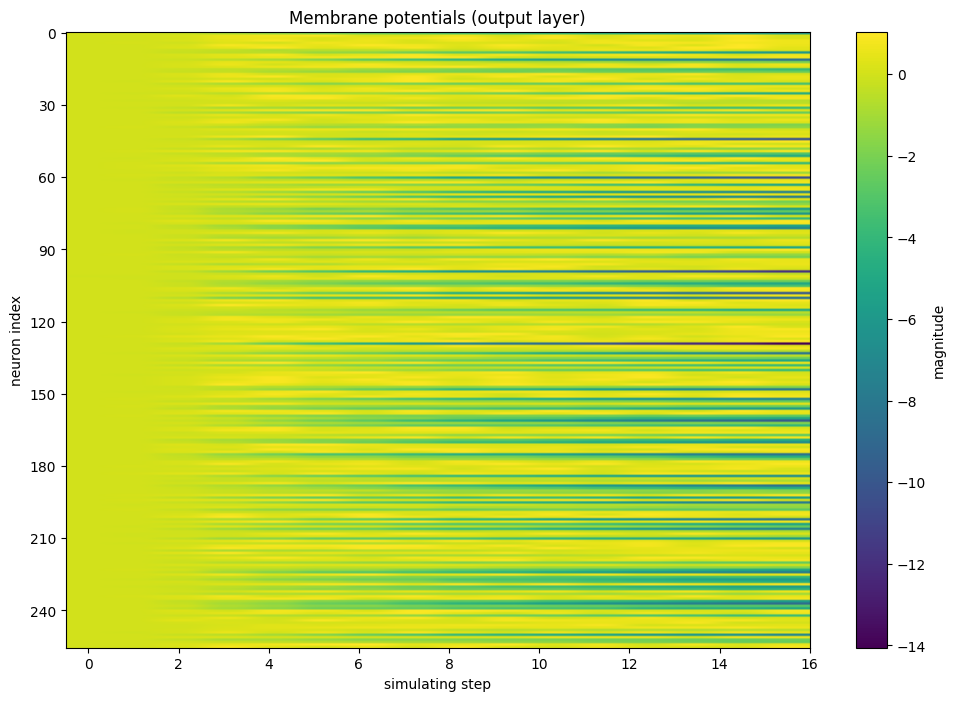

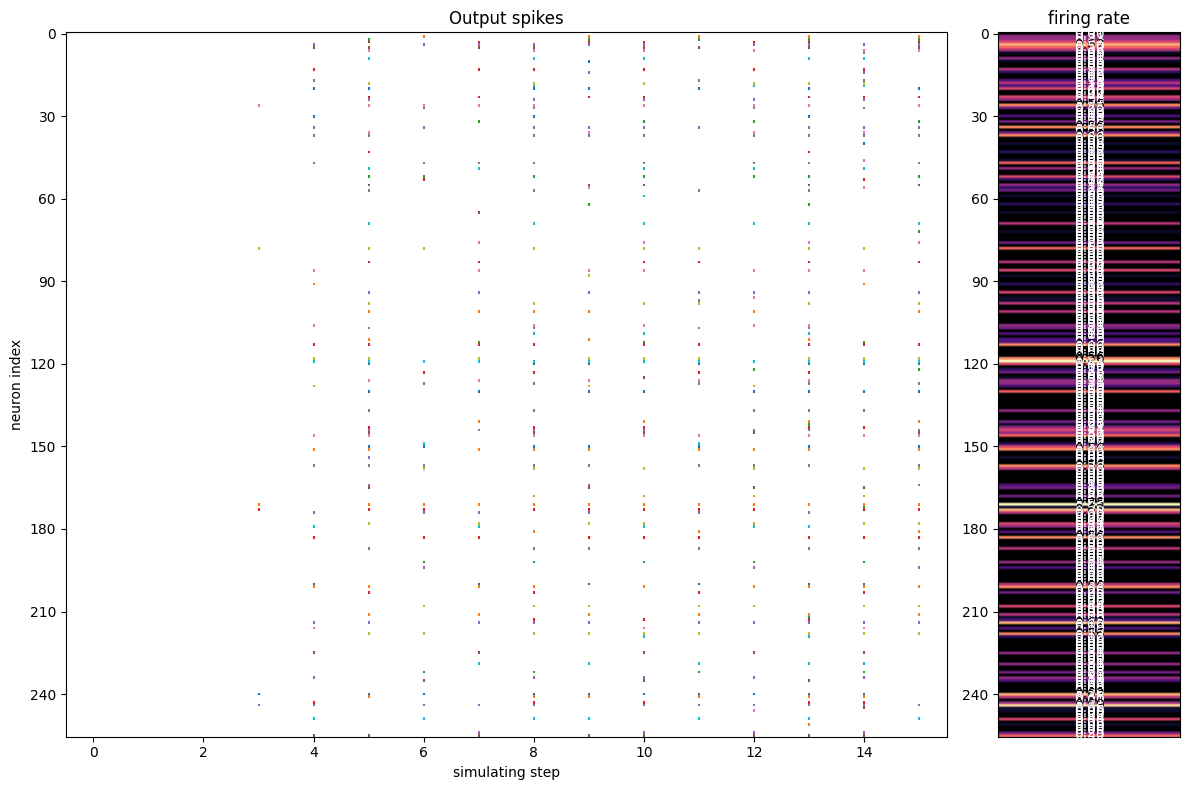

In [48]:
try_visualize_converted(conv_snn_max, a_test_dataset, T=16, index=3373, device=device)
try_visualize_converted(conv_snn_99, a_test_dataset, T=16, index=3373, device=device)

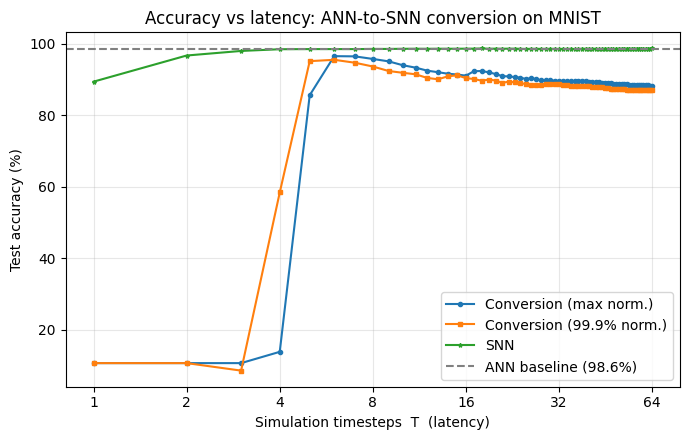

In [49]:
import matplotlib.pyplot as plt



T = range(1, 65)                      # x-axis: timesteps 1..64
ann_acc = ANN_RESULTS['ANN'].accuracy * 100                       # your ANN baseline for reference

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(T, curve_max,  marker="o", ms=3, label='Conversion (max norm.)')
ax.plot(T, curve_99, marker="s", ms=3, label='Conversion (99.9% norm.)')
ax.plot(T, curve_base_snn, marker="*", ms=3, label='SNN')
ax.axhline(ann_acc, ls="--", color="grey", label=f'ANN baseline ({ann_acc:.1f}%)')

ax.set_xlabel("Simulation timesteps  T  (latency)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Accuracy vs latency: ANN-to-SNN conversion on MNIST")
ax.set_xscale("log", base=2)          # timesteps span 1..64 — log base-2 spreads them out
ax.set_xticks([1, 2, 4, 8, 16, 32, 64]) ## [2**i for i in range(int(math.log2(T_max)) + 1)]
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())   # show 1,2,4.. not 2^0,2^1
ax.grid(alpha=.3)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("accuracy_vs_latency.png", dpi=150)
plt.show()

# Analytical Estimation

Lemaire argues tha simply counting the synaptic operations is insufficient. their metric includes:

$$
E
=
E_{\mathrm{mem}}
+
E_{\mathrm{ops+addr}}
$$

Energy comes from
- memory accesses
- synaptic operations
- addressing operations


Th memory model additionally considers reads/writes associated with:
- input data
- parameters/weights
- membrane potentials
- outputs

For SNNs, membrane potentials introduce additional memory operations, while sparse spike activity can reduce weight and input/output accesss

## Level 1: Computational activity (what the network is doing)


spikes_per_neuron_per_inference < 1.72 is the theoretical indicator of possible energy advantage under the analytical assumptions.

Measure the:
- input spikes
- output spikes
- spikes per layer
- total spikes
- spike rate
- timesteps







In [50]:
!pip install pynvml
!pip install psutil

## Locate Neurons

BaseNode is SpikingJelly's parent class. IFNode, LIFNode, ParametricLIFNode, EIFNode all inherit from it, so isinstance(mod, (neuron.BaseNode,)) matches every one.

In [51]:
best_model

ANN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [52]:
conv_snn_max

GraphModule(
  (features): Module(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (spiking_0): Module(
      (scaler0): VoltageScaler(0.586466, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.705130, step_mode=s)
    )
    (spiking_1): Module(
      (scaler0): VoltageScaler(0.347066, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1

In [53]:
ann=best_model

In [54]:
print(ann.named_modules()) # <generator object Module.named_modules at 0x784175277010>

<generator object Module.named_modules at 0x7f9dfc541250>


In [55]:
for name, mod in ann.named_modules():
  print("Name:", name)
  print("Module:", mod)

Name: 
Module: ANN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)
Name: features
Module: Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=

In [56]:
for name, mod in conv_snn_max.named_modules():
  print("Name:", name)
  print("Module:", mod)

Name: 
Module: GraphModule(
  (features): Module(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (spiking_0): Module(
      (scaler0): VoltageScaler(0.586466, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.705130, step_mode=s)
    )
    (spiking_1): Module(
      (scaler0): VoltageScaler(0.347066, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )

In [57]:
# BaseNode is SpikingJelly's parent class.
# IFNode, LIFNode, ParametricLIFNode, EIFNode all inherit from it,
# so isinstance(mod, (neuron.BaseNode,)) should appear in a converted ann2snn.

for name, mod in conv_snn_max.named_modules():
  if isinstance(mod, neuron.BaseNode):
    print("Name:", name)
    print("Module:", mod)

Name: features.spiking_0.if_node
Module: IFNode(
  v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
)
Name: features.spiking_1.if_node
Module: IFNode(
  v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
)
Name: classifier.spiking_0.if_node
Module: IFNode(
  v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
)
Name: classifier.spiking_1.if_node
Module: IFNode(
  v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
)


In [58]:

# for execution position. Hooks fire in the order data flows through the network.
# which neuron belongs to which layer
counter = {"i": 0}

def hook(m, inp, out):
    idx = counter["i"]; counter["i"] += 1
    t = out[0] if isinstance(out, (tuple, list)) else out
    n = t.numel() // max(t.shape[0], 1)
    print((idx, name, n, "neu"))

hooks = []

x0, _ = next(iter(a_test_dataloader))
example_input = x0[:1].to(device)

conv_snn_max.eval()

for name, mod in conv_snn_max.named_modules():
  if isinstance(mod, neuron.BaseNode):
    print("Name:", name)
    print("Module:", mod)
    hooks.append(mod.register_forward_hook(hook))

with torch.no_grad():
    functional.reset_net(conv_snn_max)
    for _ in range(8):
        conv_snn_max(example_input.to(DEVICE))
for h in hooks:
    h.remove()
functional.reset_net(conv_snn_max)

Name: features.spiking_0.if_node
Module: IFNode(
  v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
)
Name: features.spiking_1.if_node
Module: IFNode(
  v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
)
Name: classifier.spiking_0.if_node
Module: IFNode(
  v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
)
Name: classifier.spiking_1.if_node
Module: IFNode(
  v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
  (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
)
(0, 'classifier.spiking_1.scaler1', 25088, 'neu')
(1, 'classifier.spiking_1.scaler1', 12544, 'neu')
(2, 'classifier.spiking_1.scaler1', 512, 'neu')
(3, 'classifier.spiking_1.scaler1', 256, 'neu')
(4, 'classifier.spiking_1.scaler1', 25088, 'neu'

In [59]:
conv_snn_max.eval()

def synhook(m, inp, out):
    idx = counter["i"]; counter["i"] += 1
    t = out[0] if isinstance(out, (tuple, list)) else out
    n = t.numel() // max(t.shape[0], 1)
    print((idx, name, n, "syn"))

for name, mod in conv_snn_max.named_modules():
  if isinstance(mod, (nn.Conv2d, nn.Linear)):
    print("Name:", name)
    print("Module:", mod)
    hooks.append(mod.register_forward_hook(synhook))

with torch.no_grad():
    functional.reset_net(conv_snn_max)
    for _ in range(8):
        conv_snn_max(example_input.to(DEVICE))
for h in hooks:
    h.remove()
functional.reset_net(conv_snn_max)

Name: features.0
Module: Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
Name: features.3
Module: Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
Name: classifier.1
Module: Linear(in_features=3136, out_features=512, bias=True)
Name: classifier.4
Module: Linear(in_features=512, out_features=256, bias=True)
Name: classifier.6
Module: Linear(in_features=256, out_features=10, bias=True)
(32, 'classifier.spiking_1.scaler1', 25088, 'syn')
(33, 'classifier.spiking_1.scaler1', 12544, 'syn')
(34, 'classifier.spiking_1.scaler1', 512, 'syn')
(35, 'classifier.spiking_1.scaler1', 256, 'syn')
(36, 'classifier.spiking_1.scaler1', 10, 'syn')
(37, 'classifier.spiking_1.scaler1', 25088, 'syn')
(38, 'classifier.spiking_1.scaler1', 12544, 'syn')
(39, 'classifier.spiking_1.scaler1', 512, 'syn')
(40, 'classifier.spiking_1.scaler1', 256, 'syn')
(41, 'classifier.spiking_1.scaler1', 10, 'syn')
(42, 'classifier.spiking_1.scaler1', 25088, 'syn')
(43, '

In [60]:
SYNAPTIC_TYPES = (nn.Conv2d, nn.Linear) # layers with weights
NEURON_TYPES   = (neuron.BaseNode,) # the spiking neurons

Lemaire: An Analyticla Esimation "The energy consumption of single operations (addition, multiplication and memory accesses) are drawn from the literature [15] for 45nm CMOS technology. For addition and multiplication with 32-bit integers, we use respectively 0.1pJ and 3.1pJ. For SRAM memory accesses, we compute a linear interpolation function based on 3 particular values: 8 kB (10pJ), 32 kB (20pJ) and 1 MB (100pJ). This function enables to compute the energy cost of a memory access knowing the memory size (i.e. knowing the network hyper-parameters)."

[ Ten Lessons From Three Generations Shaped Google's TPUv4i : Industrial Product](https://www.semanticscholar.org/paper/Ten-Lessons-From-Three-Generations-Shaped-Google%E2%80%99s-Jouppi-Yoon/309fb5c6ed6d7ec85281ee315760df342e6c4fcc)


### 45 nm Energy Consumption Breakdown

| Operation | Energy | Code Constant / Variable |
| :--- | :--- | :--- |
| **Int 32 add** | 0.1 pJ | `E_ADD_INT32` |
| **Int 32 multiply** | 3.1 pJ | `E_MULT_INT32` |
| **IEEE FP32 add** | 0.9 pJ | `E_ADD_FP32` |
| **IEEE FP32 multiply** | 3.7 pJ | `E_MULT_FP32` |
| **8 KB SRAM Access** | 10.0 pJ | `_SRAM_POINTS` |
| **32 KB SRAM Access** | 20.0 pJ | `_SRAM_POINTS` |
| **1 MB (1024 KB) SRAM Access** | 100.0 pJ | `_SRAM_POINTS` |


In [61]:
# Energy Constants (45 nm Process)
# Energy values are in picojoules (pJ)

E_ADD_INT32  = 0.1e-12
E_MULT_INT32 = 3.1e-12
E_ADD_FP32   = 0.9e-12
E_MULT_FP32  = 3.7e-12

_SRAM_POINTS = [(8.0, 10e-12), (32.0, 20e-12), (1024.0, 100e-12)]
BYTES_PER_WORD = 4

Bigger memory, longer wires means more energy. But th model layers aren't 8 or 32 or 1024 kB. features.0 is 102.31 kB. So you price is guessed in between by drawing straight lines between the known dots and reading off the line.

In [62]:
# 8 kB   ->	10 pJ
# 32 kB  ->	20 pJ
# 1024 kB (1 MB) ->	100 pJ
def get_sram_energy(size_kb: float) -> float: # Lemaire's Method
    """Estimates SRAM access energy (pJ) using linear interpolation."""
    if size_kb <= _SRAM_POINTS[0][0]:
        return _SRAM_POINTS[0][1]
    if size_kb >= _SRAM_POINTS[-1][0]:
        return _SRAM_POINTS[-1][1]

    for i in range(len(_SRAM_POINTS) - 1):
        x1, y1 = _SRAM_POINTS[i]
        x2, y2 = _SRAM_POINTS[i+1]
        if x1 <= size_kb <= x2:
            return y1 + (size_kb - x1) * (y2 - y1) / (x2 - x1)
    return _SRAM_POINTS[0][1]

def total_energy(int_adds=0, int_mults=0, fp_adds=0, fp_mults=0, sram_accesses=0, sram_size_kb=8) -> float:
    """Calculates total energy in pJ based on operations and memory accesses."""
    compute = (int_adds * E_ADD_INT32) + (int_mults * E_MULT_INT32) + (fp_adds * E_ADD_FP32) + (fp_mults * E_MULT_FP32)
    memory = sram_accesses * get_sram_energy(sram_size_kb)
    return compute + memory

In [86]:
get_sram_energy(8)

1e-11

In [63]:
# MAC = Multiply-Accumulate. Multiply two numbers, add the result to a running total:
# total += weight * input

# ACC = ACCumulate. only addition. no multiply:
# total += weight

@dataclass
class EnergyModel:
    e_add: float = E_ADD_INT32
    e_mult: float = E_MULT_INT32
    label: str = "int32"

    @property
    def e_acc(self) -> float: # An accumulate is just an add. This exists so the equations can say e_acc
        return self.e_add

    @property
    def e_mac(self) -> float: # A MAC is "multiply-accumulate": multiply two numbers, then add the result to a running total.
        return self.e_add + self.e_mult


INT32_MODEL = EnergyModel(E_ADD_INT32, E_MULT_INT32, "int32")
FP32_MODEL  = EnergyModel(E_ADD_FP32,  E_MULT_FP32,  "fp32")

In [65]:
# Cin, Hin, Win, Cout, Hout, Wout, Hk, Wk, S    # conv geometry
# Nin, Nout                                     # fc geometry

from typing import Optional

# Describes one weighted layer: one Conv2d or one Linear.
# For Lemaire's Equation: Eq. 1 needs Cout·Hk·Wk for the accumulation count;
# Eq. 7 needs the same for parameter reads; Eq. 16 needs it for addressing.
@dataclass
class LayerSpec:
    name: str
    kind: str # 'conv' | 'fc'
    exec_order: int
    has_bias: bool

    Cin: int = 0; Hin: int = 0; Win: int = 0
    Cout: int = 0; Hout: int = 0; Wout: int = 0
    Hk: int = 1; Wk: int = 1; S: int = 1
    Nin: int = 0
    Nout: int = 0

    neuron_name: Optional[str] = None
    neuron_count: int = 0 # neuron_count is neurons per sample, which is the denominator of the Davidson & Furber metric.
    neuron_is_lif: bool = False

    theta_in: float = 0.0           # spike EVENTS arriving, summed over T Eq. 1/2, 13 (Lemaire, θ_l)
    theta_out: float = 0.0          # spike EVENTS emitted by the linked neuron Lemaire, θ_{l-1}
    analog_input: bool = False      # True -> encoder layer, dense MACs
    input_scale: float = 1.0        # VoltageScaler lambda, if detected

    @property
    def n_out_positions(self) -> int:
        return self.Cout * self.Hout * self.Wout if self.kind == "conv" else self.Nout

    @property
    def n_weights(self) -> int:
        if self.kind == "conv":
            return self.Cout * self.Cin * self.Hk * self.Wk
        return self.Nin * self.Nout

    @property
    def n_bias(self) -> int:
        return (self.Cout if self.kind == "conv" else self.Nout) if self.has_bias else 0

    @property
    def n_in_elements(self) -> int:
        return self.Cin * self.Hin * self.Win if self.kind == "conv" else self.Nin

Topology of Layers

```
profile_topology(model, x0[:1], device, probe_T=8)
    ├─ syn_hook fires      → name, kind, exec_order, has_bias, geometry
    ├─ syn_hook fires ×8   → distinct values collected into seen_values
    ├─ neu_hook fires      → exec_order, neurons per sample, is-LIF flag
    ├─ after probe         → analog_input, input_scale
    └─ linking step        → neuron_name, neuron_count, neuron_is_lif
```

In [69]:
# runs one forward pass with hooks attached to every Conv2d, Linear, and spiking neuron.
# It records each layer's shapes, kernel size, stride, which neuron follows it,
# and how many neurons that is. for Lemaire's equations, expectd to be modular,
# it reads it off the live model.

import math

# Records:
# - Networks shape (channels, kernel size, input and output dimensions)
# - Which spiking neuron sits immediately after it
# - How many neurons that is
# - Whether that neuron is LIF (has leak) or IF (no leak)
# - Whether the layer receives spikes or analog numbers
# - If spikes, what they've been multiplied by

def profile_topology(model,example_input,device, probe_T=8):
    model.eval() # evaluation mode: disables Dropoff(p=0.4)
    specs = {} # Dictionary of layer_name -> LayerSpec
    order = [] # List of tuples Execution Order - Each entry is  (position, name, "syn" | "neu") -> helps to wokout which neuron follows which layer
    neuron_info = {} # neuron_name -> (position, neuron count, is it LIF)
    seen_values = {} # Layer name -> the set of distinct values ever seen at its input. This is how spiking is distinguished from analog.
    counter = {"i": 0} # A counter shared by both hooks, so every layer gets a unique execution position.
    hooks = [] # registered hooks

    # A hook only receives (m, inp, out) so it never learns its own layer's name.
    # So syn_hook("features.0", mod) returns a hook (function closure) that has "features.0" baked into it.
    # syn_hook can be called once per layer to manufacture a custom hook for each.
    def syn_hook(name, mod): # spies on the Conv2d or LinearLayer
        def hook(m, inp, out):
            """
            out - the result what cam out
            inp - a tuple of what went in
            m - the layer itself
            """
            x = inp[0] # incoming tensor
            with torch.no_grad():
                u = torch.unique(x.detach()) # torch.unique returns the sorted distinct values, which is the whole spiking detector.
                # Binary spikes -> [0., 1.] have two values
                # Scaled spikes -> [0., 1.8827] have two values
                # An image -> thousands of values
                if u.numel() <= 8: # Eight or fewer distinct values so as to record them all.
                    seen_values.setdefault(name, set()).update(
                        round(float(v), 6) for v in u) # gets the set for this layer, creating an empty one if it's the first time
                else:
                    seen_values.setdefault(name, set()).add(float("nan")) # More than eight values means definitely analog. storing would be wasteful so Nan means 'analog'
            if name in specs: # The hook fires 8 times (once per probe timestep). Shape only needs recording once, so exits out on repeats.
                return
            idx = counter["i"]; counter["i"] += 1 # Stamp this layer with its execution position and bump the counter.
            if isinstance(m, nn.Conv2d):
                # For a conv layer. Tensor shapes are [batch, channels, height, width], so index 1 is channels, 2 is height, 3 is width.
                # Input shape gives Cin/Hin/Win, output shape gives Cout/Hout/Wout.
                # m.in_channels is ignored as its motr accurate to read from the tensor incase of LazyConv2d
                sp = LayerSpec(name=name, kind="conv", exec_order=idx,
                               has_bias=m.bias is not None, # if model/converted model has biases, DirectSNN uses bias=False
                               Cin=x.shape[1], Hin=x.shape[2], Win=x.shape[3],
                               Cout=out.shape[1], Hout=out.shape[2], Wout=out.shape[3],
                               Hk=m.kernel_size[0], Wk=m.kernel_size[1], S=m.stride[0]) # S=m.stride[0] takes only the vertical stride.
            else:
                # Linear layers are simpler and aren't lazy by the time we get here, so in_features and out_features can be read directly.
                sp = LayerSpec(name=name, kind="fc", exec_order=idx,
                               has_bias=m.bias is not None,
                               Nin=m.in_features, Nout=m.out_features)
            specs[name] = sp
            order.append((idx, name, "syn")) # Stores the linear layer it, and logs it as a synaptic layer executed at position idx
        return hook

    def neu_hook(name, mod): # the spy on spiking neurons
        def hook(m, inp, out):
            """
            out - the result what cam out
            inp - a tuple of what went in
            m - the layer itself
            """
            if name in neuron_info: # once is enough
                return
            idx = counter["i"]; counter["i"] += 1
            t = out[0] if isinstance(out, (tuple, list)) else out
            n = t.numel() // max(t.shape[0], 1) # most neurons return a plain tensor, but some variants return a tuple, this handles both cases
            # numel() is the total element count across the whole batch. Dividing by shape[0] (the batch size) gives neurons per sample.
            # max(..., 1) guards against a zero-length batch causing a division by zero.
            neuron_info[name] = (idx, n, isinstance(m, neuron.LIFNode))
            # The third element is the leak flag. LIF neurons decay their membrane potential
            # every timestep, which is a multiply, so they pay T * N MACs. IF neurons don't. Converted is all IF, also DirectSNN is all LIF
            order.append((idx, name, "neu"))
        return hook

 # attaching th spies(registering the hooks)
    for name, mod in model.named_modules():
        if isinstance(mod, SYNAPTIC_TYPES): # (nn.Conv2d, nn.Linear)
            hooks.append(mod.register_forward_hook(syn_hook(name, mod)))
        elif isinstance(mod, NEURON_TYPES): # neuron.BaseNode is the parent class of IFNode, LIFNode and the rest, so isinstance matches all of them.
            hooks.append(mod.register_forward_hook(neu_hook(name, mod)))

    with torch.no_grad():
        functional.reset_net(model) # reset_net clears every membrane potential to its starting value.
        for _ in range(probe_T):
            model(example_input.to(device))
    for h in hooks:
        h.remove() # Detach the spies.
    functional.reset_net(model) # Reset again, so the model is left exactly as found.

    for name, sp in specs.items():
        raw = seen_values.get(name, set())
        has_many = any(math.isnan(v) for v in raw)
        nonzero = sorted(v for v in raw if not math.isnan(v) and v != 0.0) # both spiking and analog tensors contain zeros.
        if has_many or len(nonzero) > 1:
            sp.analog_input = True # Many values, or more than one distinct non-zero value, means analog.
            sp.input_scale = 1.0
        else:
            sp.analog_input = False # Exactly one distinct non-zero value means binary-scaled spikes,
            sp.input_scale = nonzero[0] if nonzero else 1.0

    order.sort() # Sorts by the first tuple element, idx, putting everything back into execution order.
    for i, (idx, name, kind) in enumerate(order):
        if kind != "syn": # For each synaptic layer, scan forward until the first spiking neuron is found. That's its neuron. break stops at the first match.
            continue
        for j in range(i + 1, len(order)):
            if order[j][2] == "neu":
                nname = order[j][1]
                _, cnt, is_lif = neuron_info[nname]
                specs[name].neuron_name = nname
                specs[name].neuron_count = cnt
                specs[name].neuron_is_lif = is_lif
                break

    return sorted(specs.values(), key=lambda s: s.exec_order) # Hand back the layer specs in execution order, such that the per-layer table reads top to bottom like the network.

In [72]:
base_specs = profile_topology(conv_snn_max, example_input.to(DEVICE), DEVICE)

base_specs

[LayerSpec(name='features.0', kind='conv', exec_order=0, has_bias=True, Cin=1, Hin=28, Win=28, Cout=32, Hout=28, Wout=28, Hk=3, Wk=3, S=1, Nin=0, Nout=0, neuron_name='features.spiking_0.if_node', neuron_count=25088, neuron_is_lif=False, theta_in=0.0, theta_out=0.0, analog_input=True, input_scale=1.0),
 LayerSpec(name='features.3', kind='conv', exec_order=2, has_bias=True, Cin=32, Hin=14, Win=14, Cout=64, Hout=14, Wout=14, Hk=3, Wk=3, S=1, Nin=0, Nout=0, neuron_name='features.spiking_1.if_node', neuron_count=12544, neuron_is_lif=False, theta_in=0.0, theta_out=0.0, analog_input=False, input_scale=1.70513),
 LayerSpec(name='classifier.1', kind='fc', exec_order=4, has_bias=True, Cin=0, Hin=0, Win=0, Cout=0, Hout=0, Wout=0, Hk=1, Wk=1, S=1, Nin=3136, Nout=512, neuron_name='classifier.spiking_0.if_node', neuron_count=512, neuron_is_lif=False, theta_in=0.0, theta_out=0.0, analog_input=False, input_scale=2.881296),
 LayerSpec(name='classifier.4', kind='fc', exec_order=6, has_bias=True, Cin=0, 

In [74]:
import copy

def count_activity(model, specs, loader, T, device, max_batches=None):
    """
    Per sample, summed over all T timesteps:
      theta_in  = number of NONZERO input elements (spike events)
      theta_out = number of spikes emitted by the following neuron

    For the analog encoder layer theta_in is the value sum; it is not a spike
    count and is not consumed by the dense path, kept only for reference.
    """
    specs = copy.deepcopy(specs) # Returns a new list rather than mutating the input.
    by_name = {s.name: s for s in specs}
    ev_in = {s.name: 0.0 for s in specs}
    ev_out = {}
    hooks = []

    def syn_hook(name, analog):
        def hook(m, inp, out):
            x = inp[0].detach()
            ev_in[name] += float(x.sum().item() if analog
                                 else (x != 0).sum().item()) # For spiking inputs, count events & for the analog encoder, sum values
        return hook

    def neu_hook(name):
        def hook(m, inp, out):
            t = out[0] if isinstance(out, (tuple, list)) else out
            ev_out[name] = ev_out.get(name, 0.0) + float((t.detach() != 0).sum().item())
        return hook

    wanted = {s.neuron_name for s in specs if s.neuron_name}
    for name, mod in model.named_modules(): # Hooks fire on all T calls,
        if name in by_name and isinstance(mod, SYNAPTIC_TYPES):
            hooks.append(mod.register_forward_hook(
                syn_hook(name, by_name[name].analog_input)))
        elif name in wanted and isinstance(mod, NEURON_TYPES):
            hooks.append(mod.register_forward_hook(neu_hook(name)))

    model.eval()
    n = 0
    with torch.no_grad():
        for b, (x, _) in enumerate(loader):
            if max_batches is not None and b >= max_batches:
                break
            x = x.to(device)
            functional.reset_net(model)
            for _ in range(T): # Accumulation
                model(x)
            n += x.size(0)
    for h in hooks:
        h.remove()
    functional.reset_net(model)

    n = max(n, 1)
    for s in specs:
        s.theta_in = ev_in[s.name] / n # Divide by total samples such that thea per sample is summed over T
        s.theta_out = ev_out.get(s.neuron_name, 0.0) / n if s.neuron_name else 0.0
    return specs

In [77]:
specs = count_activity(conv_snn_max, base_specs, a_test_dataloader,8, device,max_batches=20)
specs

[LayerSpec(name='features.0', kind='conv', exec_order=0, has_bias=True, Cin=1, Hin=28, Win=28, Cout=32, Hout=28, Wout=28, Hk=3, Wk=3, S=1, Nin=0, Nout=0, neuron_name='features.spiking_0.if_node', neuron_count=25088, neuron_is_lif=False, theta_in=831.2703887939454, theta_out=11463.6390625, analog_input=True, input_scale=1.0),
 LayerSpec(name='features.3', kind='conv', exec_order=2, has_bias=True, Cin=32, Hin=14, Win=14, Cout=64, Hout=14, Wout=14, Hk=3, Wk=3, S=1, Nin=0, Nout=0, neuron_name='features.spiking_1.if_node', neuron_count=12544, neuron_is_lif=False, theta_in=5396.26640625, theta_out=7437.66484375, analog_input=False, input_scale=1.70513),
 LayerSpec(name='classifier.1', kind='fc', exec_order=4, has_bias=True, Cin=0, Hin=0, Win=0, Cout=0, Hout=0, Wout=0, Hk=1, Wk=1, S=1, Nin=3136, Nout=512, neuron_name='classifier.spiking_0.if_node', neuron_count=512, neuron_is_lif=False, theta_in=4203.53515625, theta_out=356.903125, analog_input=False, input_scale=2.881296),
 LayerSpec(name='c

In [81]:
T = 8
problems = []
for s in specs:
    if s.neuron_count:
        rate = s.theta_out / (s.neuron_count * T) # checks firing rate <= 1 so An IF or LIF neuron with reset fires at most once per timestep.
        # if rate > 1 means  values are being summed and events not being counted.
        if rate > 1.0 + 1e-6:
            problems.append(
                f"{s.name}: firing rate {rate:.3f} > 1 -- theta_out is not "
                f"an event count")
    if not s.analog_input:
        cap = s.n_in_elements * T # validate input capacity, A layer with n_in_elements inputs, run for T steps, has n_in_elements * T slots. Can't exceed it.
        if s.theta_in > cap * (1 + 1e-6): # handle lost spikes
            problems.append(
                f"{s.name}: theta_in {s.theta_in:.0f} exceeds capacity "
                f"{cap} ({s.n_in_elements} inputs * T={T})")
for prev, cur in zip(specs[:-1], specs[1:]):
        if cur.analog_input or prev.theta_out == 0:
            continue
        if cur.theta_in > prev.theta_out * (1 + 1e-6):
            problems.append(
                f"{cur.name}: theta_in {cur.theta_in:.0f} > theta_out of "
                f"{prev.name} ({prev.theta_out:.0f}) -- impossible through pooling")

In [83]:
if problems:
   msg = "Activity validation failed:\n  " + "\n  ".join(problems)

In [ ]:
def validate_activity(specs, T, strict=True):
    """
    Validate Counted Activity
    """
    problems = []
    for s in specs:
        if s.neuron_count:
            rate = s.theta_out / (s.neuron_count * T) # checks firing rate <= 1 so An IF or LIF neuron with reset fires at most once per timestep.
            # if rate > 1 means  values are being summed and events not being counted.
            if rate > 1.0 + 1e-6:
                problems.append(
                    f"{s.name}: firing rate {rate:.3f} > 1 -- theta_out is not "
                    f"an event count")
        if not s.analog_input:
            cap = s.n_in_elements * T # validate input capacity, A layer with n_in_elements inputs, run for T steps, has n_in_elements * T slots. Can't exceed it.
            if s.theta_in > cap * (1 + 1e-6): # handle lost spikes
                problems.append(
                    f"{s.name}: theta_in {s.theta_in:.0f} exceeds capacity "
                    f"{cap} ({s.n_in_elements} inputs * T={T})")
    for prev, cur in zip(specs[:-1], specs[1:]):
        if cur.analog_input or prev.theta_out == 0:
            continue
        if cur.theta_in > prev.theta_out * (1 + 1e-6):
            problems.append(
                f"{cur.name}: theta_in {cur.theta_in:.0f} > theta_out of "
                f"{prev.name} ({prev.theta_out:.0f}) -- impossible through pooling")
    if problems:
        msg = "Activity validation failed:\n  " + "\n  ".join(problems)
        if strict:
            raise ValueError(msg)
        print("WARNING: " + msg)
    return problems

In [84]:
def level1_summary(specs, T):
    total_spikes = sum(s.theta_out for s in specs) # Excludes the output layer, which has no neuron and correctly contributes 0.
    total_neurons = sum(s.neuron_count for s in specs)
    return {
        "T": T,
        "total_spikes_per_sample": total_spikes,
        "total_neurons": total_neurons,
        "spikes_per_neuron_per_inference": total_spikes / total_neurons if total_neurons else 0.0, # The Davidson & Furber metric, compared against 1.72.
        "spikes_per_neuron_per_timestep": (total_spikes / total_neurons / T) if (total_neurons and T) else 0.0, # The steady-state firing rate.
    }

In [85]:
level1_summary(specs, 8)

{'T': 8,
 'total_spikes_per_sample': 19413.553125,
 'total_neurons': 38400,
 'spikes_per_neuron_per_inference': 0.505561279296875,
 'spikes_per_neuron_per_timestep': 0.06319515991210937}

# Level 2

Analytical Energy: This is the "MACs / ACCs" part of [Davidson & Furber] , checks the spikes, MACs/ACCs, rates, timesteps. and implements Lemaire's Equations

In [87]:
def sram_access_energy(size_kB: float) -> float: # look up the right per-access price on the interpolation curve.
    """Piecewise-linear SRAM access energy vs memory size (Lemaire's method).
    Assumes E_read == E_write."""
    pts = _SRAM_POINTS
    if size_kB <= pts[0][0]:
        return pts[0][1]
    for (x0, y0), (x1, y1) in zip(pts[:-1], pts[1:]):
        if size_kB <= x1:
            return y0 + (y1 - y0) * (size_kB - x0) / (x1 - x0)
    (x0, y0), (x1, y1) = pts[-2], pts[-1]
    return y1 + (y1 - y0) * (size_kB - x1) / (x1 - x0)

In [90]:
# handle Lemaire Equations (1-17)
def snn_layer_counts(s, T, fc_acc_literal=False):
    th_in, th_out = s.theta_in, s.theta_out

    if s.analog_input:
        # Static frame-based encoding: analog input repeated T times => dense MACs
        return _dense_counts(s, repeats=T, is_snn_encoder=True)

    if s.kind == "conv":
        mac = T * s.n_out_positions if s.neuron_is_lif else 0.0 # Eq. 1 (Lemaire)
        acc = (th_in * math.ceil(s.Hk / s.S) * math.ceil(s.Wk / s.S) * s.Cout
               + (T * s.n_out_positions if s.has_bias else 0.0)
               + th_out) # Eq. 1 (Lemaire)
        rd = (th_in
              + th_in * s.Cout * s.Wk * s.Hk # weightd
              + (s.n_out_positions if s.has_bias else 0.0) # bias
              + th_in * s.Cout * s.Wk * s.Hk + s.n_out_positions) # Eq. 7, 8 — parameter reads  # Eq. 9
        wr = th_out + th_in * s.Cout * s.Wk * s.Hk + s.n_out_positions
        mac_addr = th_in * 2
        acc_addr = th_in * s.Cout * s.Hk * s.Wk
    else:
        mac = T * s.Nout if s.neuron_is_lif else 0.0 # Eq. 1 (Lemaire)
        fan = (s.Nin * s.Nout) if fc_acc_literal else s.Nout # Eq. 2 fc synaptic operations, SNN (Lemaire)
        acc = th_in * fan + (T * s.Nout if s.has_bias else 0.0) + th_out
        rd = (th_in
              + th_in * s.Nout + (s.Nout if s.has_bias else 0.0)
              + (th_in + 1) * s.Nout) # Eq. 5, 6  input reads SNN (Lemaire)
        wr = th_out + th_in * s.Nout + s.Nout
        mac_addr = 0.0
        acc_addr = th_in * s.Nout

    return {
        "mac": mac, "acc": acc, "rd": rd,
        "wr": wr,"mac_addr": mac_addr, "acc_addr": acc_addr
    }


def _dense_counts(s, repeats, is_snn_encoder=False):
    if s.kind == "conv":
        mac = s.n_out_positions * s.Cin * s.Hk * s.Wk # Eq. 3, 4 synaptic operations, FNN (Lemaire) # conv
        acc = s.n_out_positions if s.has_bias else 0.0
        rd = (s.Cin * s.Cout * s.Hout * s.Wout * s.Wk * s.Hk
              + (s.Cin * s.Wk * s.Hk + (1 if s.has_bias else 0))
                * s.Cout * s.Wout * s.Hout)
        wr = s.n_out_positions
        mac_addr = 0.0
        acc_addr = (s.Cin * s.Hin * s.Win + s.n_out_positions
                    + s.Cout * s.Hk * s.Wk)
    else:
        mac = s.Nin * s.Nout # Eq. 3, 4 synaptic operations, FNN (Lemaire) # fc
        acc = s.Nout if s.has_bias else 0.0
        rd = s.Nin + (s.Nin + (1 if s.has_bias else 0)) * s.Nout  # Eq. 5, 6  input reads SNN (Lemaire) FNN conv
        wr = s.Nout
        mac_addr = 0.0
        acc_addr = s.Nin + s.Nout
    out = {
        "mac": mac, "acc": acc, "rd": rd, "wr": wr,
        "mac_addr": mac_addr, "acc_addr": acc_addr
    }
    if repeats != 1:
        out = {k: v * repeats for k, v in out.items()}
        if is_snn_encoder:
            out["rd"] += repeats * s.n_out_positions
            out["wr"] += repeats * s.n_out_positions
    return out


def ann_layer_counts(s):
    return _dense_counts(s, repeats=1)


def layer_memory_kB(s, spiking): # compute each layer's memory footprint
    words = s.n_weights + s.n_bias
    if spiking:
        words += s.n_out_positions
        words += max(s.n_in_elements // 8, 64)
    else:
        words += s.n_in_elements + s.n_out_positions
    return words * BYTES_PER_WORD / 1024.0


def counts_to_energy(counts, mem_kB, em):
    e_access = sram_access_energy(mem_kB)
    E_mem = (counts["rd"] + counts["wr"]) * e_access
    E_ops = counts["mac"] * em.e_mac + counts["acc"] * em.e_acc
    E_addr = counts["mac_addr"] * em.e_mac + counts["acc_addr"] * em.e_acc
    return {
        "E_mem": E_mem, "E_ops": E_ops, "E_addr": E_addr,
        "E_total": E_mem + E_ops + E_addr,
        "mem_kB": mem_kB, "e_access_J": e_access, **counts
    }


def analytical_energy(specs, T, em=INT32_MODEL, fc_acc_literal=False):
    rows = []
    keys = ["E_mem", "E_ops", "E_addr", "E_total", "mac", "acc", "rd", "wr"]
    snn_tot = {k: 0.0 for k in keys}
    ann_tot = {k: 0.0 for k in keys}

    for s in specs:
        sc = snn_layer_counts(s, T, fc_acc_literal=fc_acc_literal)
        ac = ann_layer_counts(s)
        se = counts_to_energy(sc, layer_memory_kB(s, True), em)
        ae = counts_to_energy(ac, layer_memory_kB(s, False), em)
        for k in keys:
            snn_tot[k] += se[k]; ann_tot[k] += ae[k]
        rows.append({
            "layer": s.name, "kind": s.kind, "analog_in": s.analog_input,
            "input_scale": s.input_scale,
            "theta_in": s.theta_in, "theta_out": s.theta_out,
            "neurons": s.neuron_count,
            "firing_rate": s.theta_out / (s.neuron_count * T) if s.neuron_count else float("nan"),
            "snn_mac": sc["mac"], "snn_acc": sc["acc"],
            "snn_rd": sc["rd"], "snn_wr": sc["wr"],
            "snn_E_mem": se["E_mem"], "snn_E_ops": se["E_ops"],
            "snn_E_addr": se["E_addr"], "snn_E_total": se["E_total"],
            "snn_mem_kB": se["mem_kB"], "snn_pJ_per_access": se["e_access_J"] * 1e12,
            "ann_mac": ac["mac"], "ann_E_total": ae["E_total"],
            "ann_mem_kB": ae["mem_kB"],
            "ratio_ann_over_snn": ae["E_total"] / se["E_total"] if se["E_total"] else float("nan"),
        })

    snn_tot["ratio_ann_over_snn"] = (ann_tot["E_total"] / snn_tot["E_total"]
                                     if snn_tot["E_total"] else float("nan"))
    df = pd.DataFrame(rows)
    if len(df):
        df["snn_pct_of_total"] = 100 * df["snn_E_total"] / snn_tot["E_total"]
    return snn_tot, ann_tot, df


def ann_baseline(ann, example_input, device,em=INT32_MODEL):
    """
    Analytical energy of the non-spiking ANN (Baseline), which would treat every layer as an
    encoder and report the ANN executed T times.
    """
    specs = profile_topology(ann, example_input, device, probe_T=1)
    keys = ["E_mem", "E_ops", "E_addr", "E_total", "mac", "acc", "rd", "wr"]
    rows, tot = [], {k: 0.0 for k in keys}
    for s in specs:
        ac = ann_layer_counts(s)
        ae = counts_to_energy(ac, layer_memory_kB(s, False), em)
        for k in keys:
            tot[k] += ae[k]
        rows.append({
            "layer": s.name, "kind": s.kind, "mac": ac["mac"],
            "rd": ac["rd"], "wr": ac["wr"], "mem_kB": ae["mem_kB"],
            "pJ_per_access": ae["e_access_J"] * 1e12,
            "E_mem": ae["E_mem"], "E_ops": ae["E_ops"],
            "E_total": ae["E_total"]
        })
    df = pd.DataFrame(rows)
    df["pct_of_total"] = 100 * df["E_total"] / tot["E_total"]
    return tot, df


@torch.no_grad()
def accuracy_vs_T(model, loader, Ts, device, spiking=True, max_batches=None):
    """SNN: accumulate output over T timesteps, then argmax.  ANN: single pass."""
    model.eval()
    rows = []
    for T in (list(Ts) if spiking else [1]):
        correct = total = 0
        for b, (x, y) in enumerate(loader):
            if max_batches is not None and b >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            if spiking:
                functional.reset_net(model)
                out = None
                for _ in range(T):
                    o = model(x)
                    out = o if out is None else out + o
            else:
                out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += y.numel()
        functional.reset_net(model)
        rows.append({"T": T, "accuracy": correct / max(total, 1), "n_eval": total})
    return pd.DataFrame(rows)


In [91]:
snn_e, ann_e, per_layer = analytical_energy(specs, 8, em=INT32_MODEL, fc_acc_literal=False)

In [92]:
snn_e

{'E_mem': 0.0037703103505323846,
 'E_ops': 6.3471362025e-06,
 'E_addr': 5.908021160937499e-07,
 'E_total': 0.0037772482888509783,
 'mac': 1806336.0,
 'acc': 5668610.024999999,
 'rd': 14757596.272656249,
 'wr': 5776060.024999999,
 'ratio_ann_over_snn': 0.2897563986528574}

In [93]:
ann_e

{'E_mem': 0.0010766242669951278,
 'E_ops': 1.78525706e-05,
 'E_addr': 5.023400000000001e-09,
 'E_total': 0.0010944818609951276,
 'mac': 5577728.0,
 'acc': 38410.0,
 'rd': 9458506.0,
 'wr': 38410.0}

In [94]:
per_layer

,layer,kind,analog_in,input_scale,theta_in,theta_out,neurons,firing_rate,snn_mac,snn_acc,...,snn_E_ops,snn_E_addr,snn_E_total,snn_mem_kB,snn_pJ_per_access,ann_mac,ann_E_total,ann_mem_kB,ratio_ann_over_snn,snn_pct_of_total
0,features.0,conv,True,1.000000,831.270389,11463.639063,25088,0.057117,1806336.0,2.007040e+05,...,5.800346e-06,2.092800e-08,1.182142e-04,99.632812,25.454259,225792,1.360802e-05,102.312500,0.115113,3.129639
1,features.3,conv,False,1.705130,5396.266406,7437.664844,12544,0.074116,0.0,3.216039e+06,...,3.216039e-07,3.453610e-07,2.579656e-04,124.312500,27.444556,3612672,2.230834e-04,145.750000,0.864780,6.829457
2,classifier.1,fc,False,2.881296,4203.535156,356.903125,512,0.087135,0.0,2.156663e+06,...,2.156663e-07,2.152210e-07,3.384779e-03,6277.531250,523.671875,1605632,8.495328e-04,6288.250000,0.250986,89.609650
3,classifier.4,fc,False,2.759093,356.903125,155.346094,256,0.075853,0.0,9.357055e+04,...,9.357055e-09,9.136720e-09,1.623604e-05,514.250000,58.891129,131072,8.217458e-06,516.000000,0.506124,0.429838
4,classifier.6,fc,False,3.613321,155.346094,0.000000,0,NaN,0.0,1.633461e+03,...,1.633461e-10,1.553461e-10,5.347659e-08,10.328125,10.970052,2560,4.021692e-08,11.078125,0.752047,0.001416
